findfont: Failed to find font weight bold, now using 400.


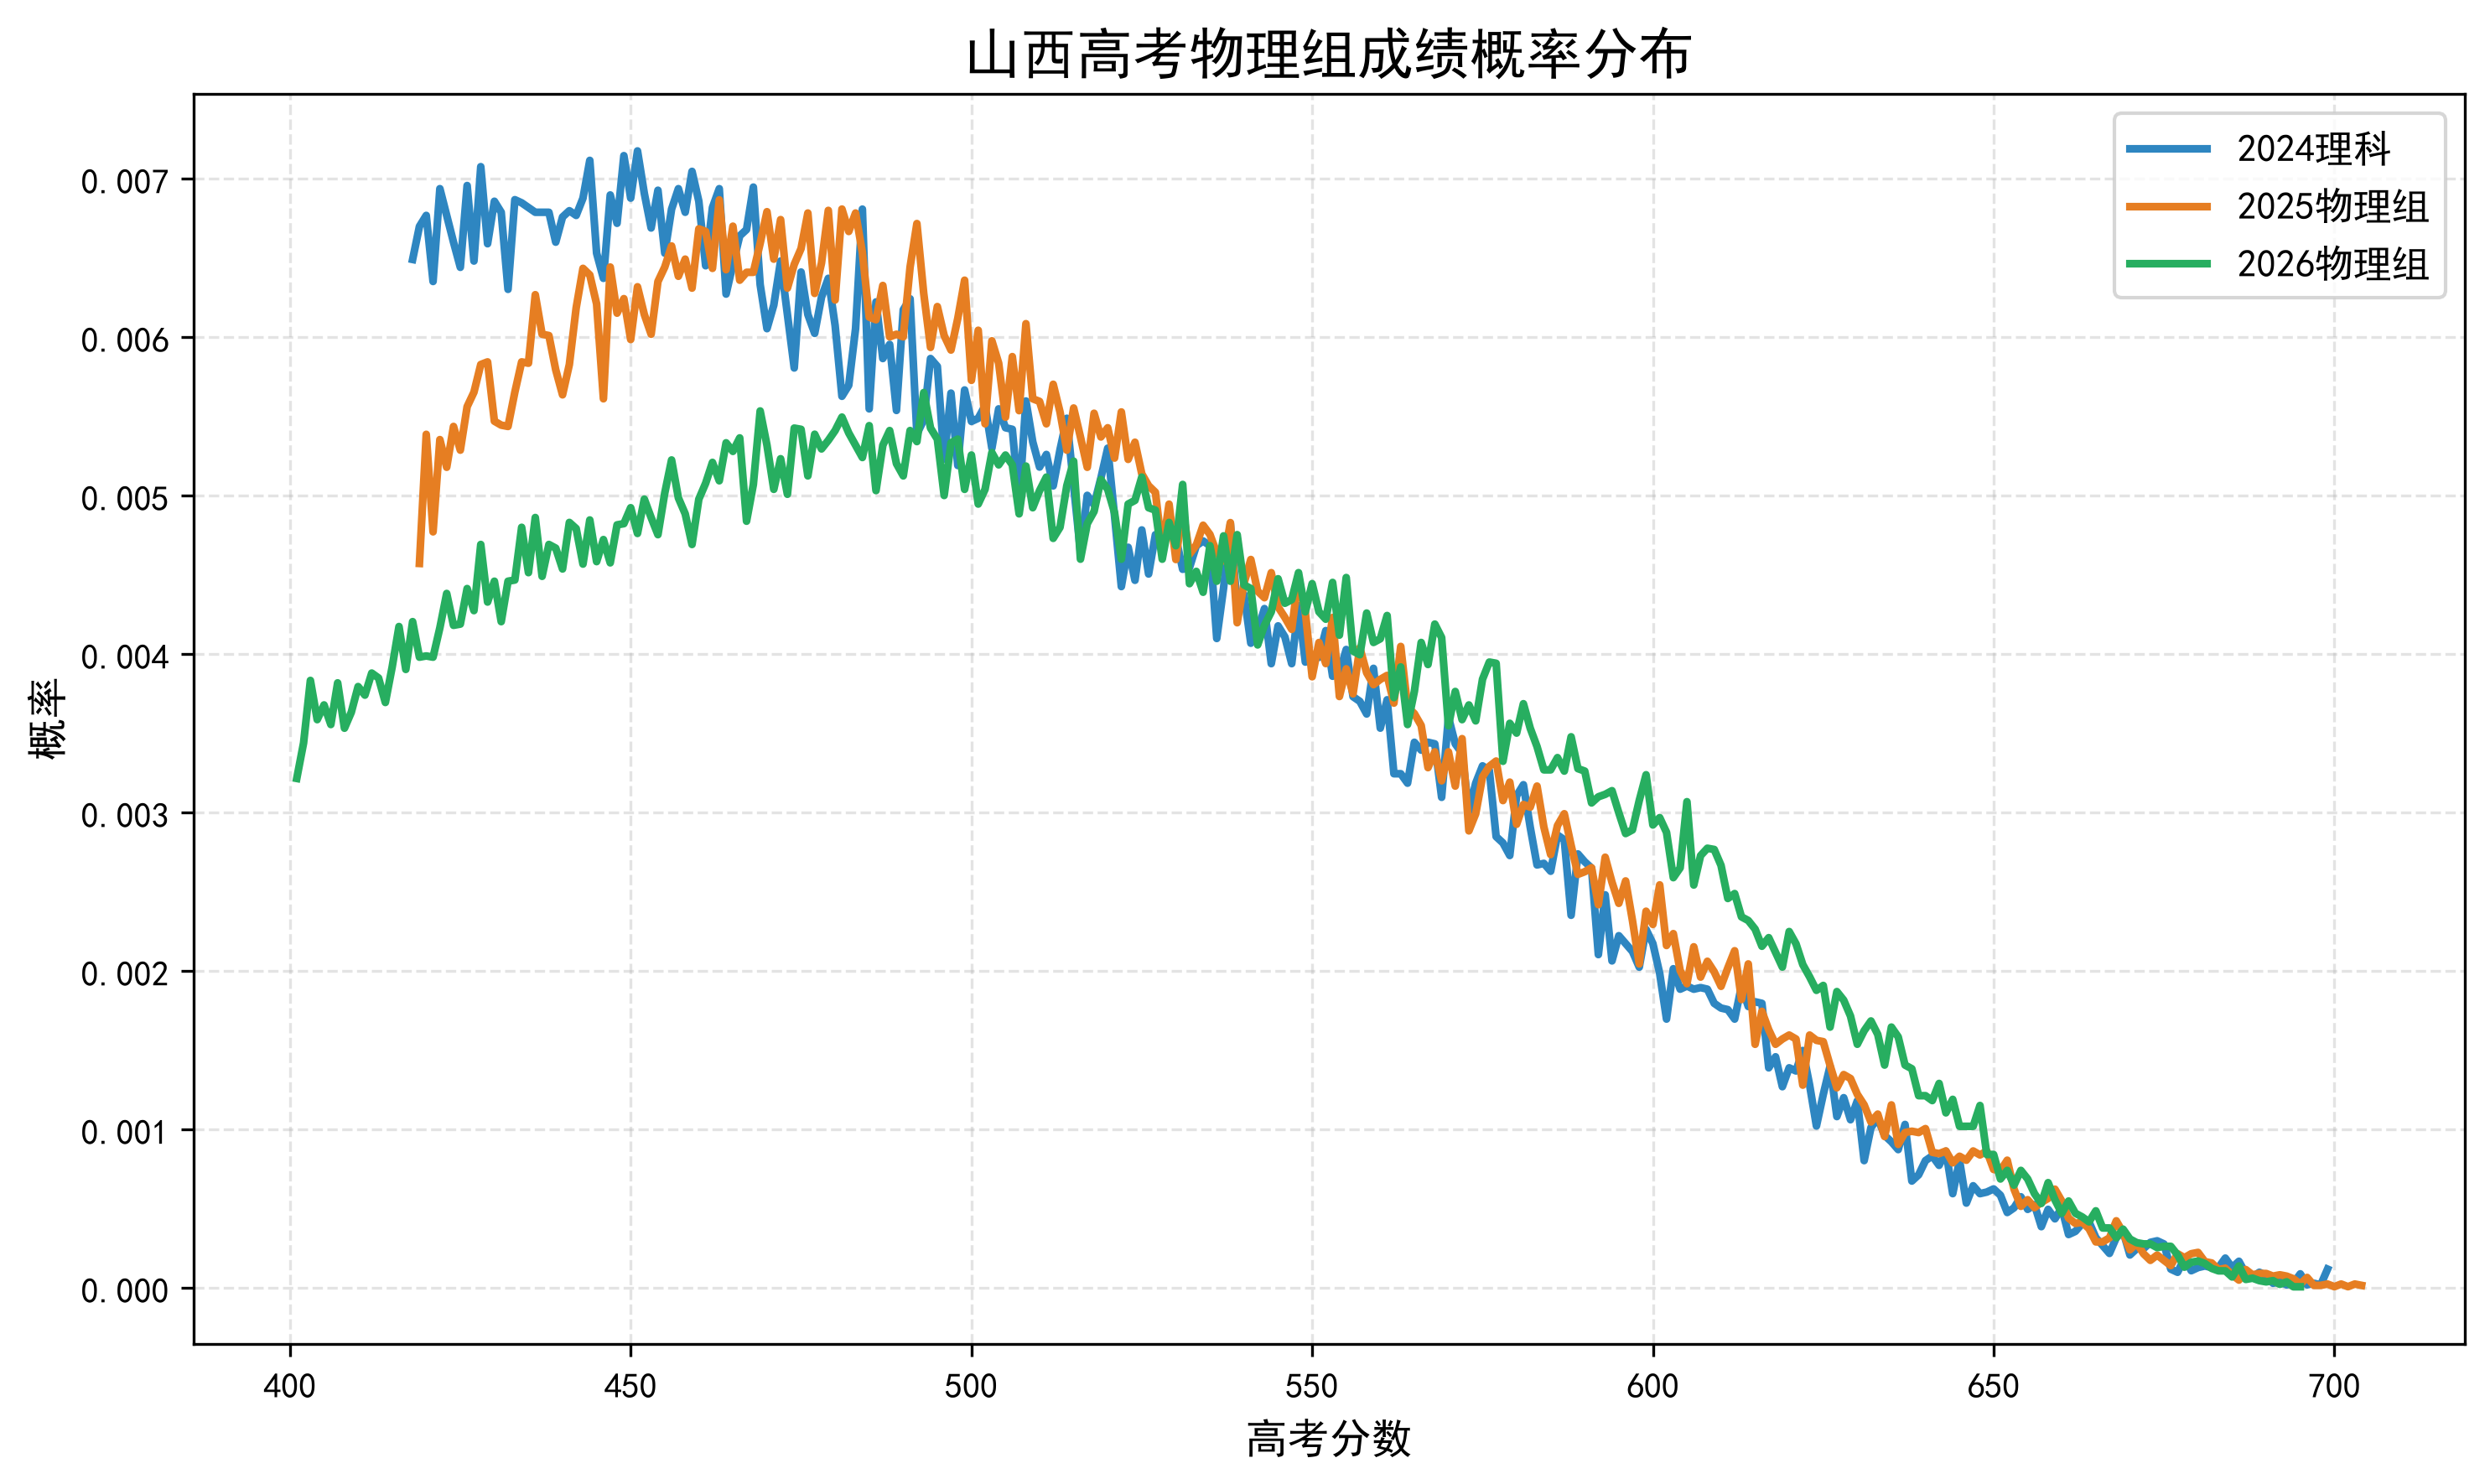

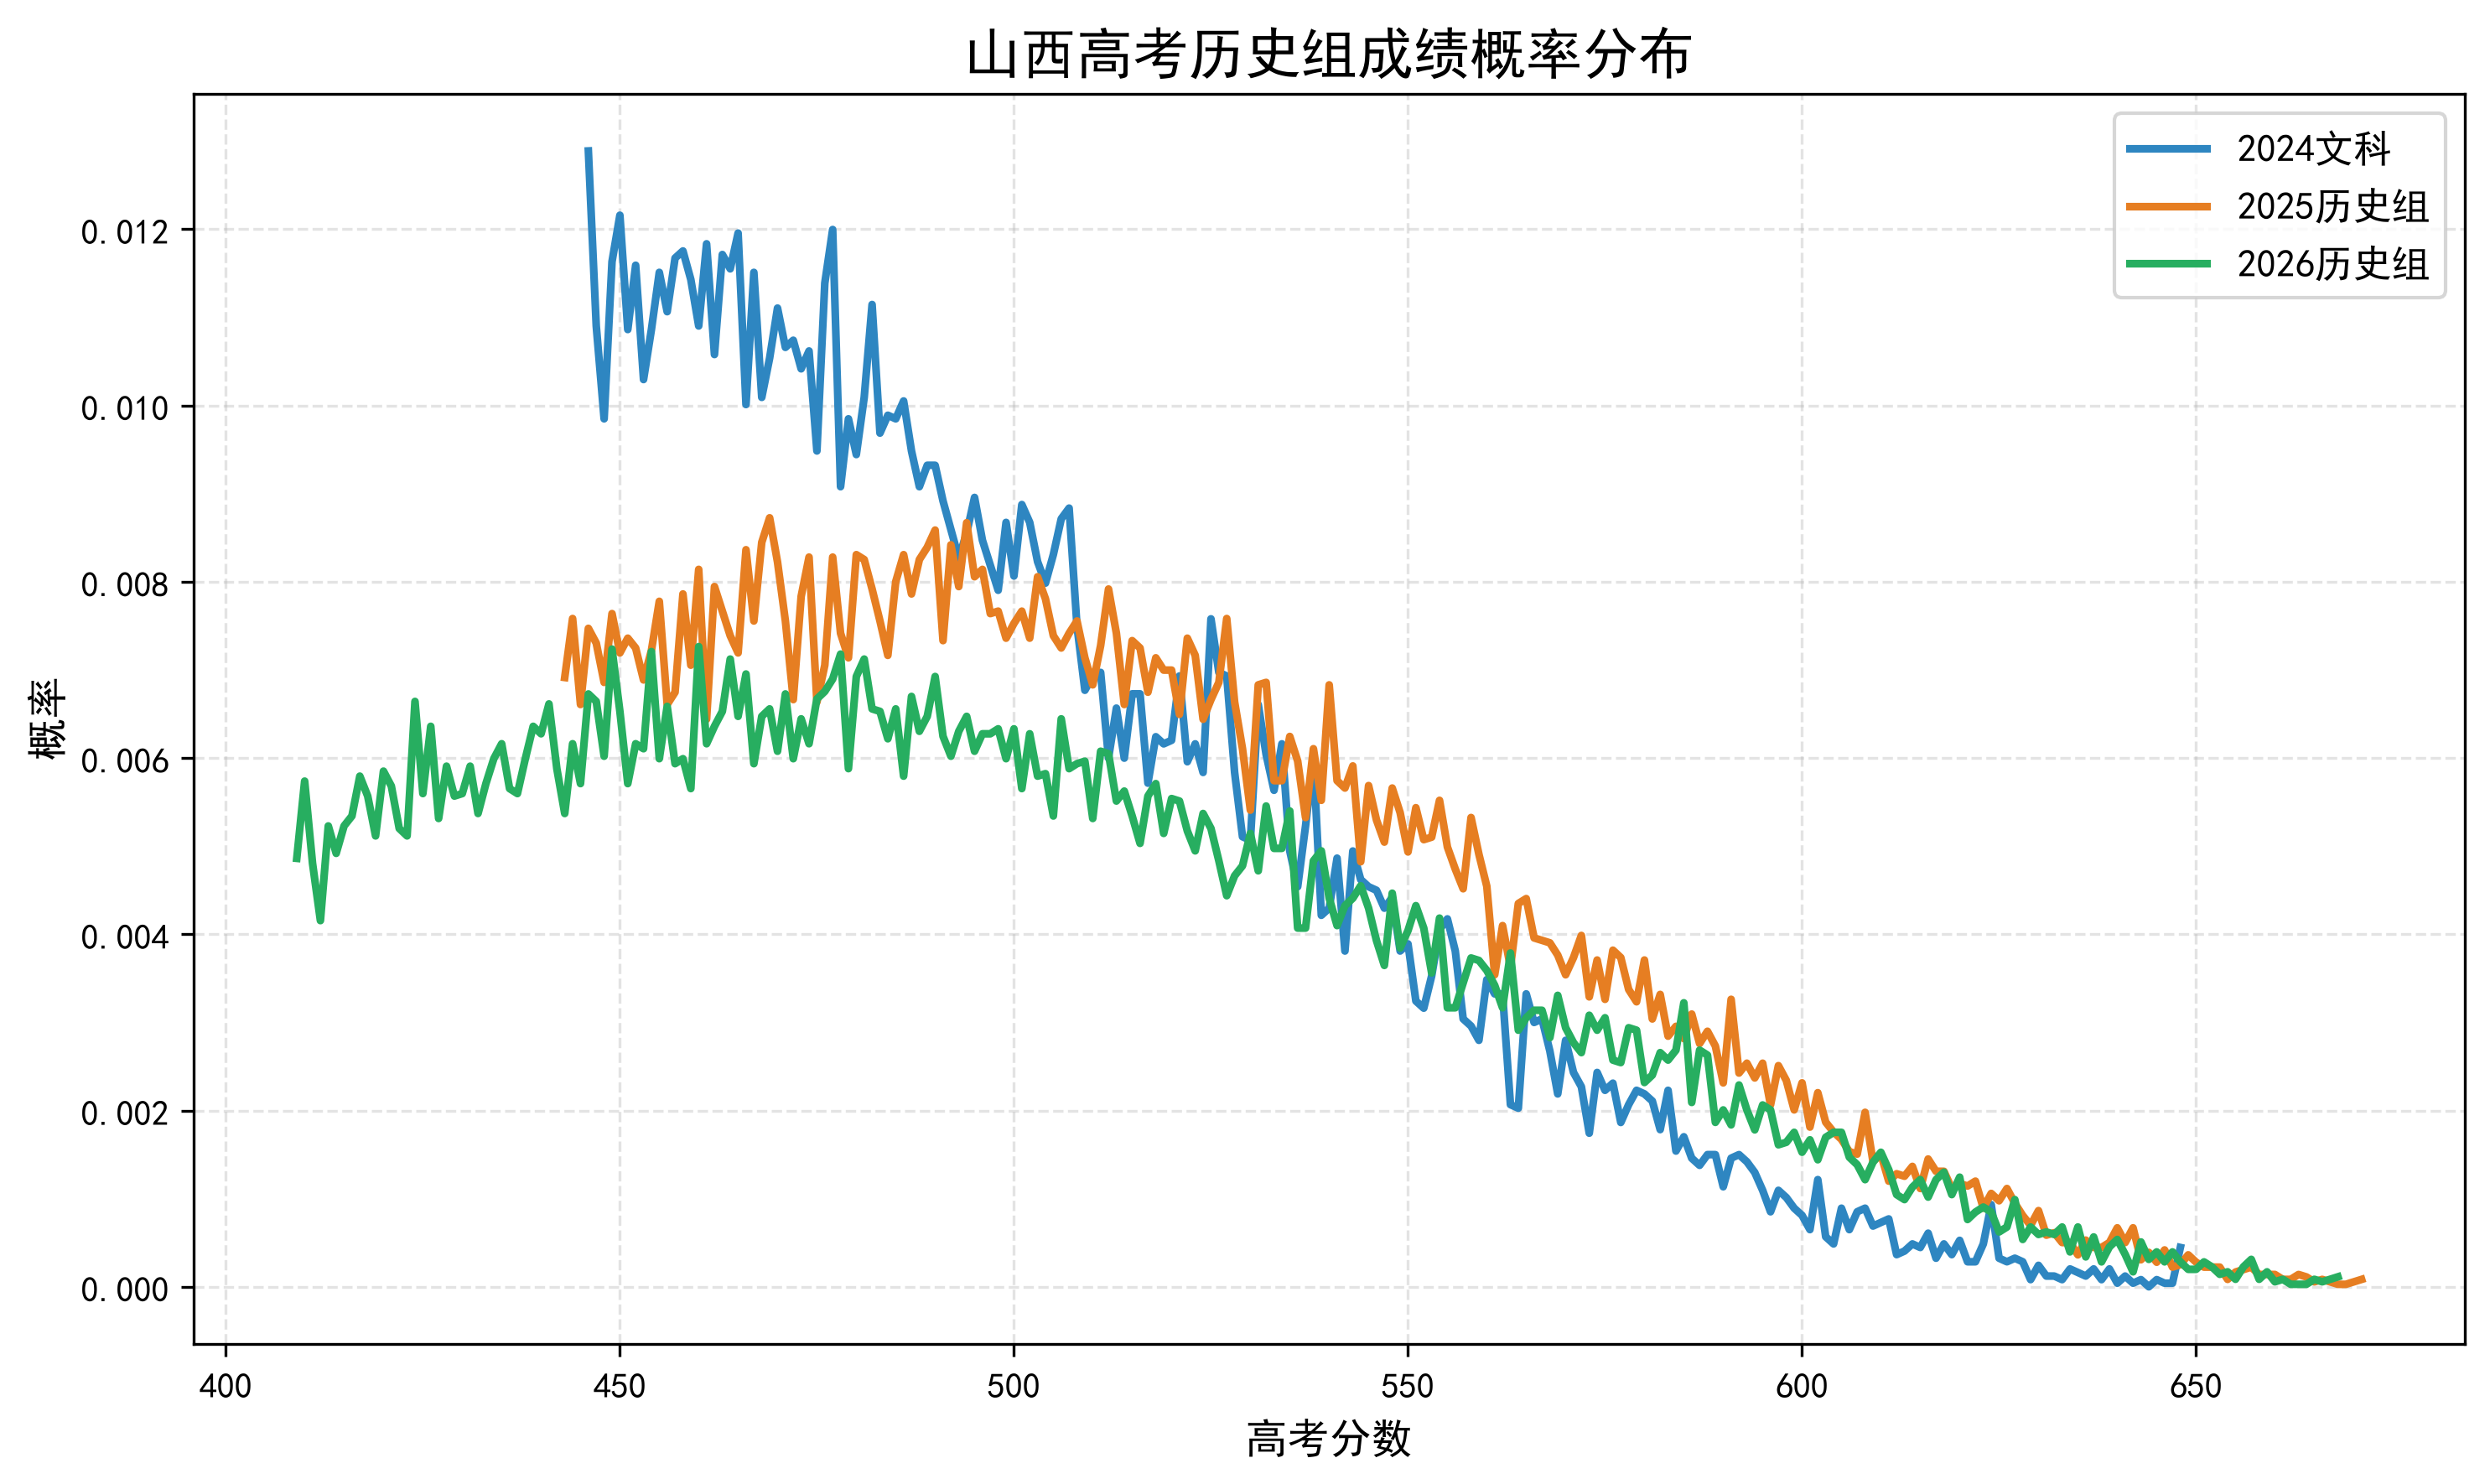

In [1]:
# ==========================================
# 山西高考分数概率分布绘制
# 问题1：新旧高考分布变化分析
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
# ---------- 中文显示 ----------
plt.rcParams['font.sans-serif'] = ['SimHei']     # 黑体
plt.rcParams['axes.unicode_minus'] = False
# ---------- 文件 ----------
files = {
    "2024理科": "shanxi_2024_science.csv",
    "2025物理组": "shanxi_2025_physics.csv",
    "2026物理组": "shanxi_2026_physics.csv",
    "2024文科": "shanxi_2024_arts.csv",
    "2025历史组": "shanxi_2025_history.csv",
    "2026历史组": "shanxi_2026_history.csv"
}
# ---------- 数据处理 ----------
def load_data(file):
    df = pd.read_csv(file)
    # 总人数
    total = df["本分人数"].sum()
    # 概率
    df["概率"] = df["本分人数"] / total
    # 按分数排序
    df = df.sort_values("分数")
    return df
data = {name: load_data(file)for name, file in files.items()}
# ---------- 绘图 ----------
def plot_distribution(names, title):
    plt.figure(figsize=(10,6), dpi=300)
    colors = ["#2E86C1", "#E67E22", "#27AE60"]
    for c, name in zip(colors, names):
        df = data[name]
        plt.plot(df["分数"], df["概率"],label=name,linewidth=2.2,color=c)
    plt.title(title,fontsize=16,fontweight="bold")
    plt.xlabel("高考分数", fontsize=12)
    plt.ylabel("概率", fontsize=12)
    plt.grid(linestyle="--",alpha=0.35)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(title+".png",dpi=300,bbox_inches="tight")
    plt.show()
# ---------- 物理组 ----------
plot_distribution(
    [
        "2024理科",
        "2025物理组",
        "2026物理组"
    ],
    "山西高考物理组成绩概率分布"
)
# ---------- 历史组 ----------
plot_distribution(
    [
        "2024文科",
        "2025历史组",
        "2026历史组"
    ],
    "山西高考历史组成绩概率分布"
)

,有效分数段,考生人数,最低分,最高分,本分人数缺失,累计人数缺失
年份组别,,,,,,
2024理科,282,"100,748",418,699,0,0
2024文科,203,"24,672",446,648,0,0
2025物理组,286,"120,275",419,704,0,0
2025历史组,229,"35,869",443,671,0,0
2026物理组,295,"129,352",401,695,0,0
2026历史组,260,"35,378",409,668,0,0


,平均分,中位数,标准差,偏度,峰度,最低分,最高分
年份组别,,,,,,,
2024理科,503.82,494.00,59.35,0.591,-0.420,418,699
2024文科,500.62,493.00,40.38,0.793,0.044,446,648
2025物理组,508.68,500.00,58.93,0.556,-0.434,419,704
2025历史组,514.42,508.00,47.09,0.550,-0.389,443,671
2026物理组,511.23,506.00,65.15,0.286,-0.790,401,695
2026历史组,496.85,491.00,55.33,0.461,-0.528,409,668


,600分以上(%),650分以上(%),680分以上(%)
年份组别,,,
2024理科,7.703,1.245,0.175
2024文科,1.893,0.000,0.000
2025物理组,8.682,1.398,0.183
2025历史组,5.325,0.284,0.000
2026物理组,11.097,1.463,0.120
2026历史组,4.636,0.246,0.000


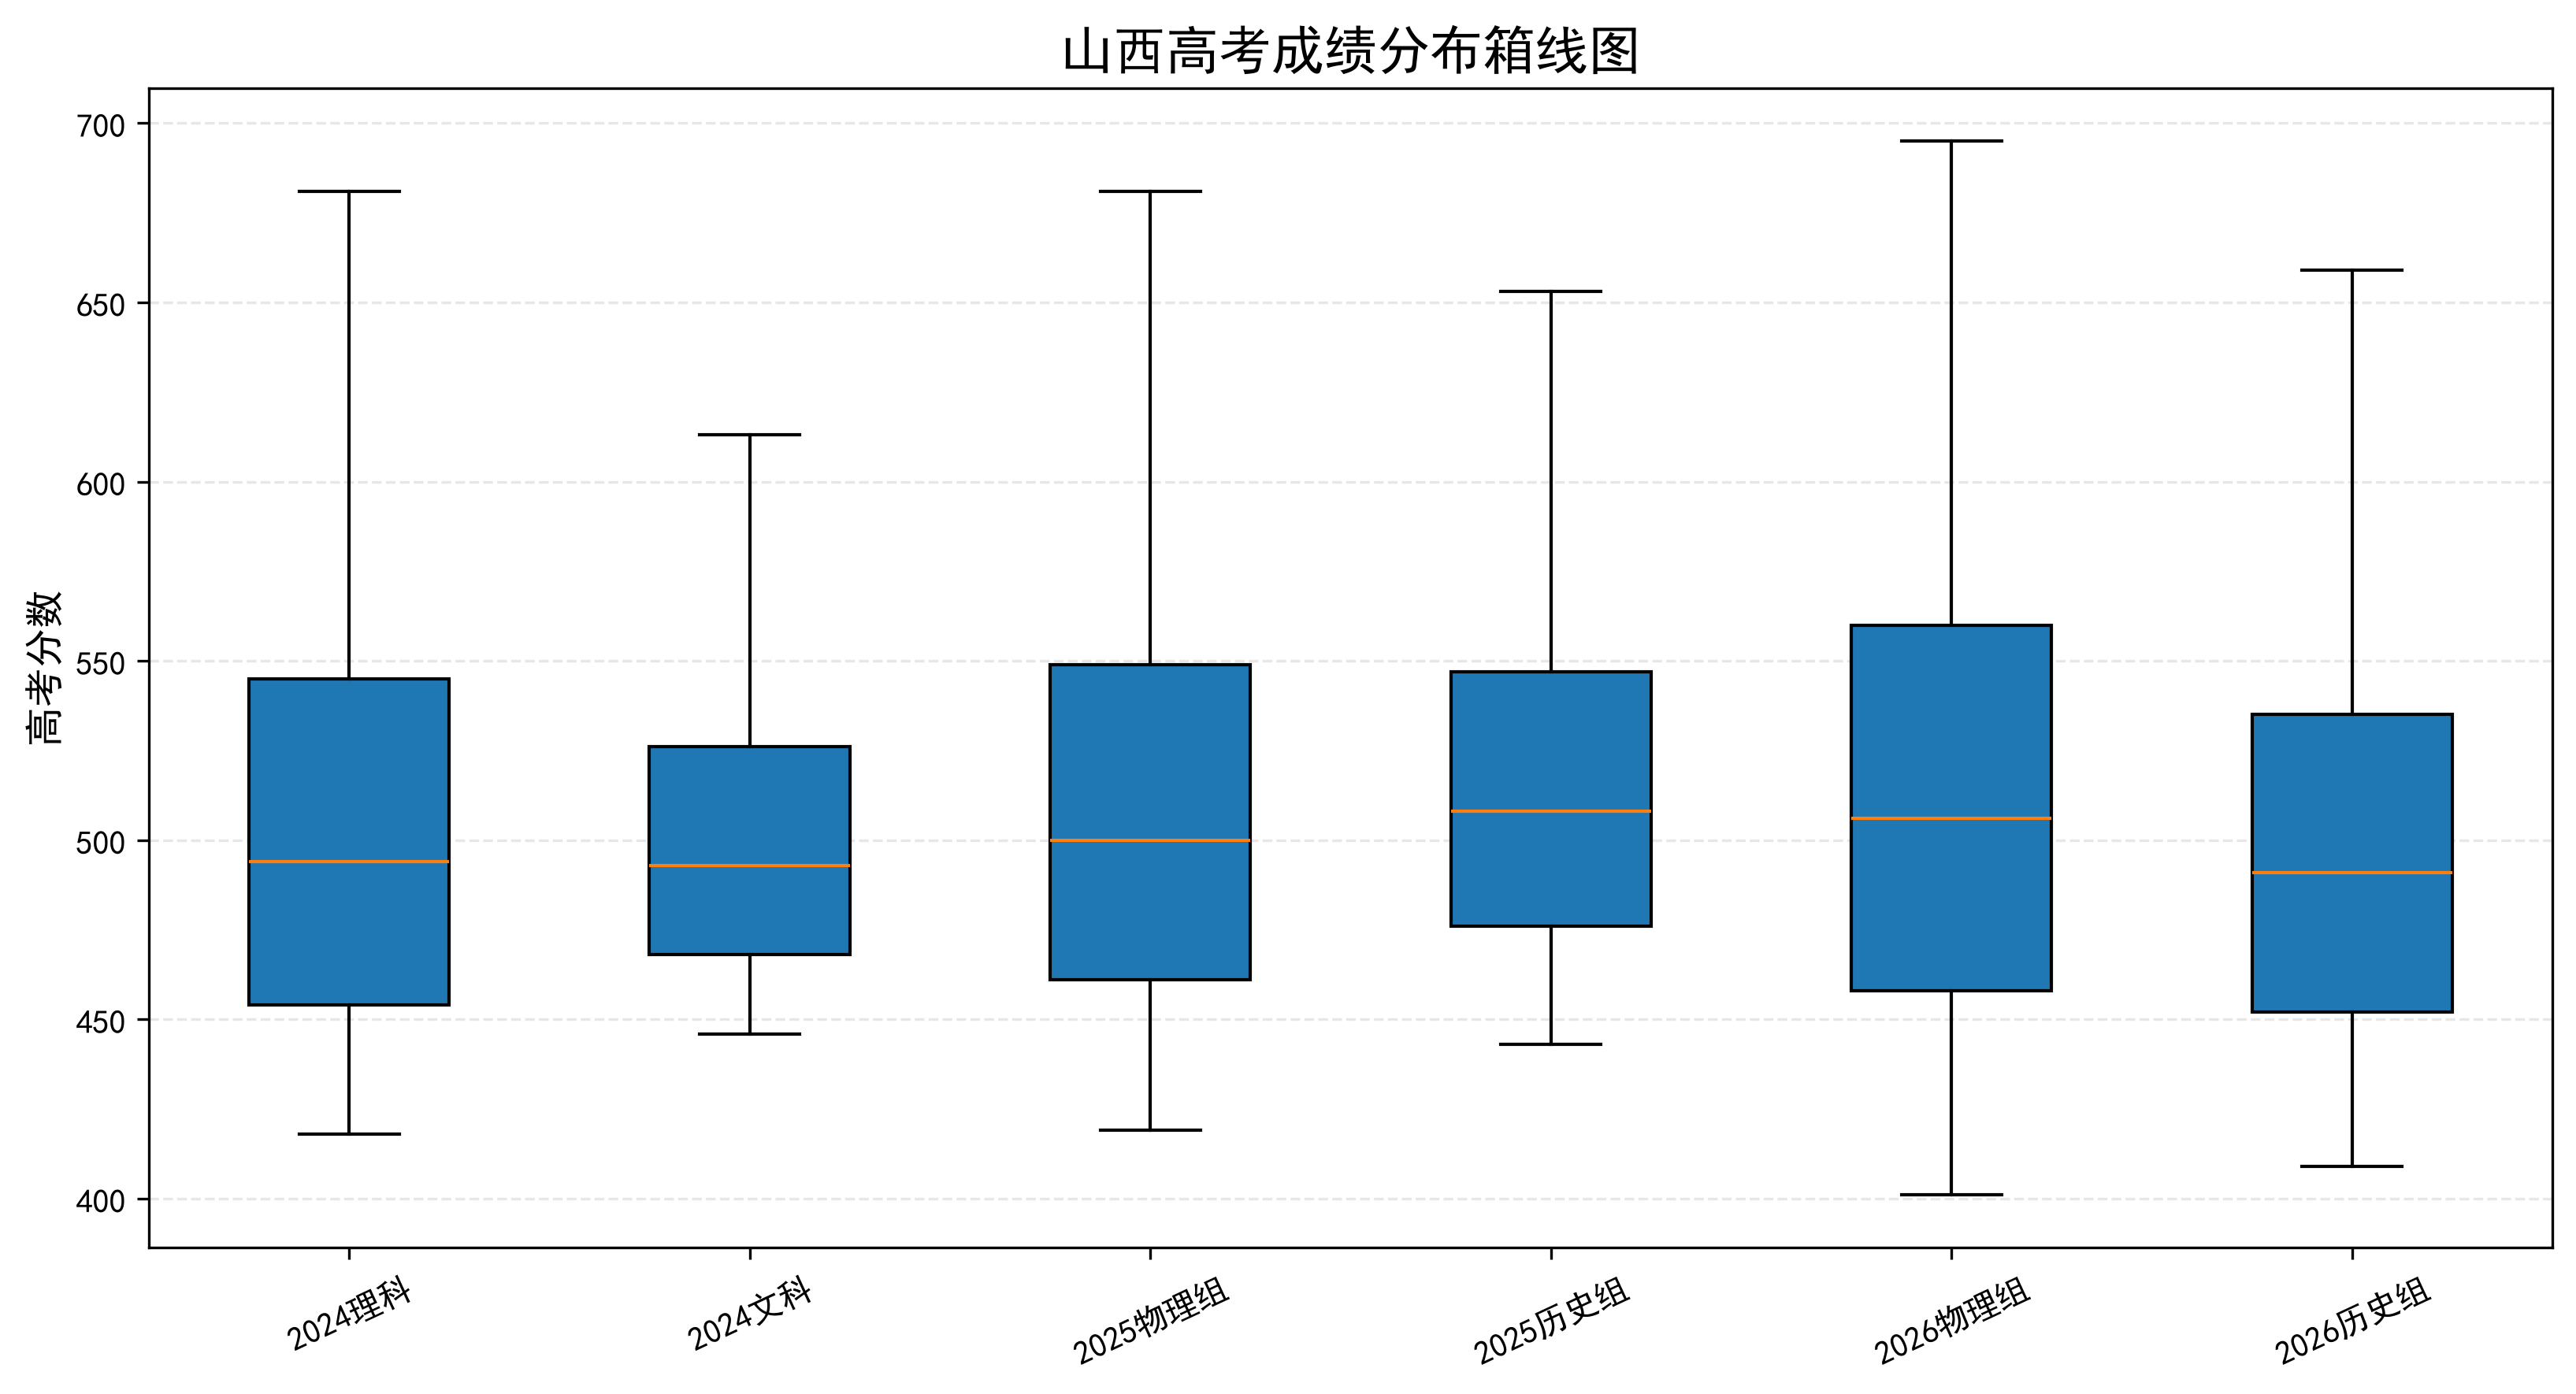

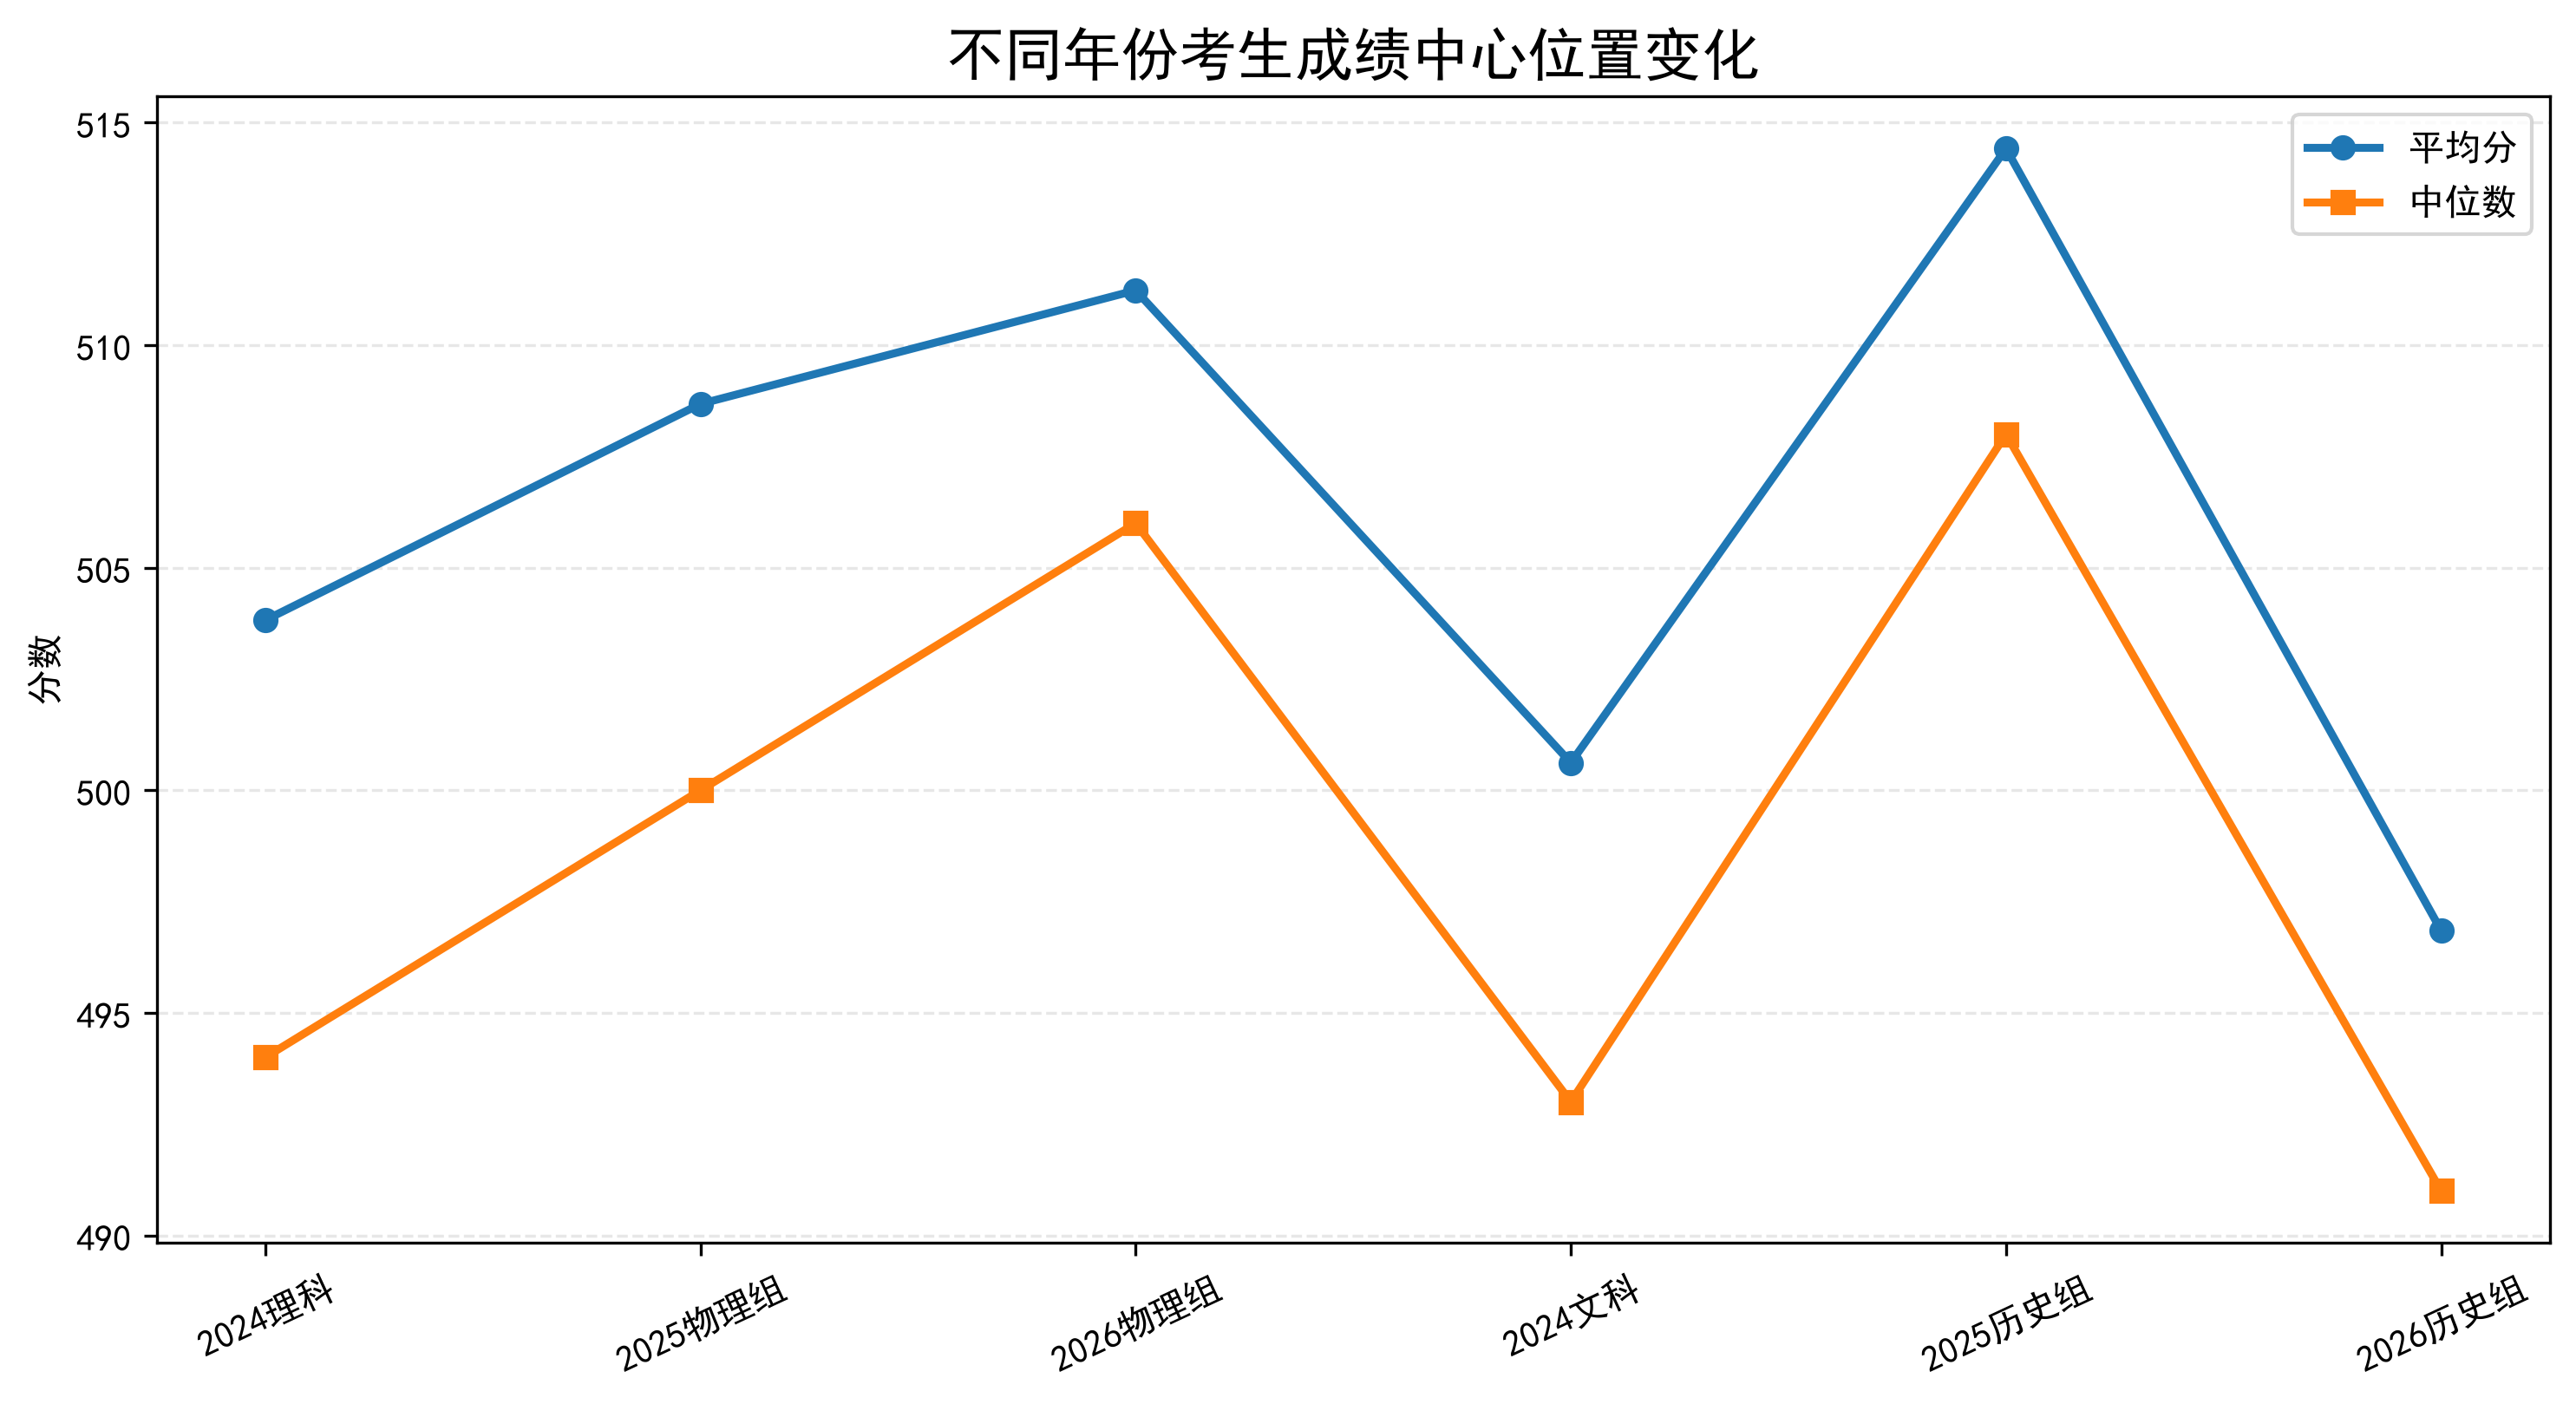

In [2]:
# ==========================================
# 问题1：高考一分一段表前期数据分析
# CSV字段：分数、本分人数、累计人数
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
# 中文显示
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
# ---------- 文件 ----------
files = {
    "2024理科": "shanxi_2024_science.csv",
    "2024文科": "shanxi_2024_arts.csv",
    "2025物理组": "shanxi_2025_physics.csv",
    "2025历史组": "shanxi_2025_history.csv",
    "2026物理组": "shanxi_2026_physics.csv",
    "2026历史组": "shanxi_2026_history.csv"
}
# ---------- 读取数据 ----------
def load_data(file):
    df = pd.read_csv(file)
    required = ["分数", "本分人数", "累计人数"]

    if not all(col in df.columns for col in required):
        raise ValueError(f"{file} 缺少必要字段：{required}")

    df = df[required].copy()
    df = df.dropna()
    df["分数"] = pd.to_numeric(df["分数"])
    df["本分人数"] = pd.to_numeric(df["本分人数"])
    df["累计人数"] = pd.to_numeric(df["累计人数"])
    return df.sort_values("分数").reset_index(drop=True)
data = {name: load_data(file) for name, file in files.items()}
# ---------- 数据基本检查 ----------
check = []
for name, df in data.items():
    check.append([
        name,
        len(df),
        int(df["本分人数"].sum()),
        int(df["分数"].min()),
        int(df["分数"].max()),
        int(df["本分人数"].isna().sum()),
        int(df["累计人数"].isna().sum())
    ])
check_table = pd.DataFrame(check, columns=[
    "年份组别", "有效分数段", "考生人数",
    "最低分", "最高分", "本分人数缺失", "累计人数缺失"
]).set_index("年份组别")
display(check_table.style.format({
    "考生人数": "{:,}",
    "最低分": "{:.0f}",
    "最高分": "{:.0f}"
}))


# ==========================================
# 描述性统计
# ==========================================
def statistics(df):
    n = df["本分人数"].sum()
    x = df["分数"]
    w = df["本分人数"]
    mean = (x * w).sum() / n
    var = (((x - mean) ** 2) * w).sum() / n
    std = np.sqrt(var)
    # 用本分人数作为频数计算偏度、峰度
    values = np.repeat(x.astype(int), w.astype(int))
    sk = skew(values)
    ku = kurtosis(values)
    median = np.median(values)
    return [mean, median, std, sk, ku,x.min(), x.max()]
result = []
for name, df in data.items():
    result.append([name] + statistics(df))
summary = pd.DataFrame(result, columns=[
    "年份组别", "平均分", "中位数", "标准差",
    "偏度", "峰度", "最低分", "最高分"
]).set_index("年份组别")
display(summary.style.format({
    "平均分": "{:.2f}",
    "中位数": "{:.2f}",
    "标准差": "{:.2f}",
    "偏度": "{:.3f}",
    "峰度": "{:.3f}",
    "最低分": "{:.0f}",
    "最高分": "{:.0f}"
}))


# ==========================================
# 高分段比例
# ==========================================
thresholds = [600, 650, 680]
high_result = []
for name, df in data.items():
    total = df["本分人数"].sum()
    row = [name]
    for threshold in thresholds:
        num = df.loc[df["分数"] >= threshold, "本分人数"].sum()
        row.append(num / total * 100)
    high_result.append(row)
high_table = pd.DataFrame(high_result, columns=[
    "年份组别", "600分以上(%)", "650分以上(%)", "680分以上(%)"
]).set_index("年份组别")
display(high_table.style.format("{:.3f}"))


# ==========================================
# 成绩分布箱线图
# ==========================================
box_data = []
labels = []
for name, df in data.items():
    scores = np.repeat(df["分数"].astype(int),df["本分人数"].astype(int))
    box_data.append(scores)
    labels.append(name)
plt.figure(figsize=(11, 6), dpi=300)
plt.boxplot(box_data,showfliers=False,patch_artist=True)
plt.xticks(range(1, len(labels) + 1), labels, rotation=25)
plt.title("山西高考成绩分布箱线图",
          fontsize=16, fontweight="bold")
plt.ylabel("高考分数", fontsize=12)
plt.xticks(rotation=25)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================================
# 统计量变化趋势
# ==========================================
plot_data = summary.loc[
    ["2024理科", "2025物理组", "2026物理组",
     "2024文科", "2025历史组", "2026历史组"]
]
plt.figure(figsize=(10, 5.5), dpi=300)
x = np.arange(len(plot_data))
plt.plot(x, plot_data["平均分"],marker="o", linewidth=2.2,label="平均分")
plt.plot(x, plot_data["中位数"],marker="s", linewidth=2.2,label="中位数")
plt.xticks(x, plot_data.index, rotation=25)
plt.ylabel("分数")
plt.title("不同年份考生成绩中心位置变化",
          fontsize=16, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Wasserstein距离矩阵：


,2024理科,2024文科,2025物理组,2025历史组,2026物理组,2026历史组
2024理科,0.00,16.46,4.86,14.25,10.16,6.97
2024文科,16.46,0.00,16.85,13.97,24.19,13.21
2025物理组,4.86,16.85,0.00,11.47,7.44,11.83
2025历史组,14.25,13.97,11.47,0.00,16.00,17.57
2026物理组,10.16,24.19,7.44,16.00,0.00,15.23
2026历史组,6.97,13.21,11.83,17.57,15.23,0.00


findfont: Failed to find font weight bold, now using 400.


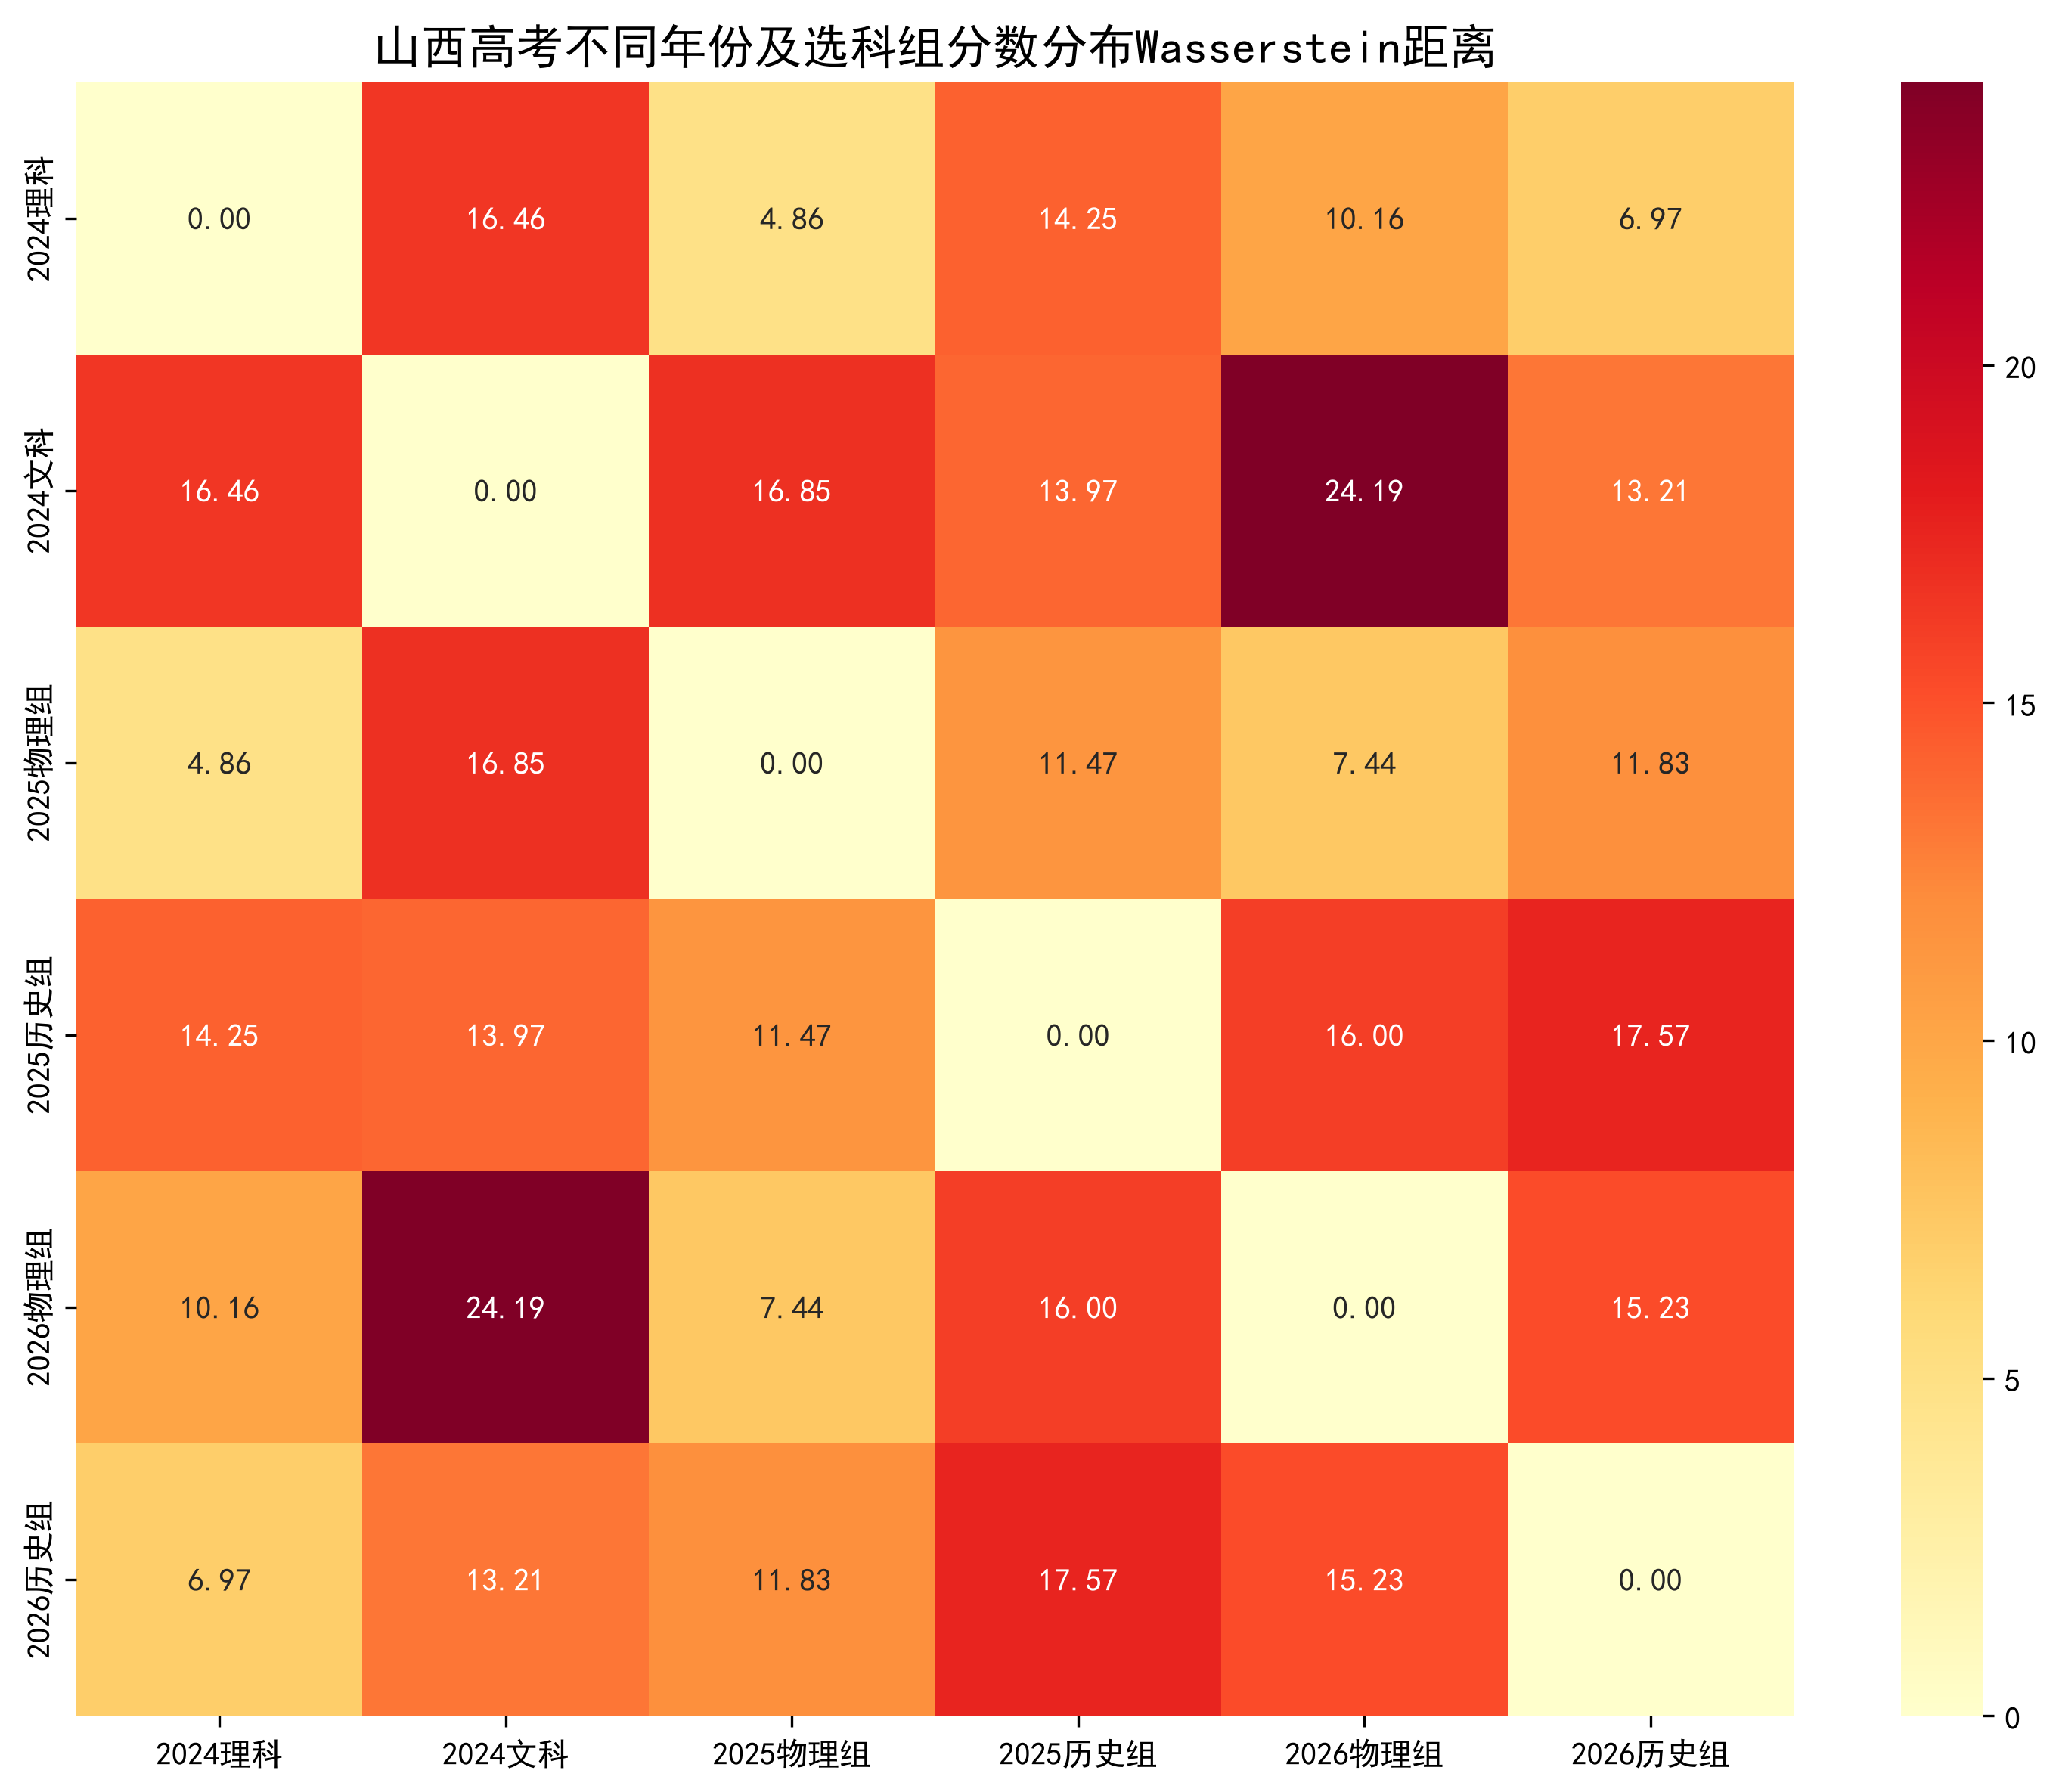

In [3]:
# ==========================================
# 问题1：Wasserstein距离计算
# 比较2024-2026山西高考分数分布差异
# 数据：一分一段表
# ==========================================
from scipy.stats import wasserstein_distance
import seaborn as sns
# ------------------------------------------------
# 将一分一段表转换为离散成绩样本
# ------------------------------------------------
def expand_scores(df):
    """
    根据一分一段表恢复成绩序列
    
    分数: 成绩
    本分人数: 该分数人数
    
    返回：
    所有考生的成绩数组
    """
    scores = np.repeat(df["分数"].values,df["本分人数"].values.astype(int))
    return scores


# ------------------------------------------------
# 读取数据
# ------------------------------------------------
score_data = {}
for name, file in files.items():
    df = pd.read_csv(file)
    # 保证字段正确
    df = df[["分数", "本分人数", "累计人数"]].dropna()
    score_data[name] = expand_scores(df)
# ------------------------------------------------
# 计算两两Wasserstein距离
# ------------------------------------------------
names = list(score_data.keys())
wasserstein_matrix = pd.DataFrame(
    np.zeros((len(names), len(names))),
    index=names,
    columns=names)
for i in range(len(names)):
    for j in range(len(names)):
        distance = wasserstein_distance(
            score_data[names[i]],
            score_data[names[j]])
        wasserstein_matrix.iloc[i,j] = distance
# 保留两位小数
wasserstein_matrix = wasserstein_matrix.round(2)
print("Wasserstein距离矩阵：")
display(wasserstein_matrix)
# ------------------------------------------------
# 热力图展示
# ------------------------------------------------
plt.figure(figsize=(10,8), dpi=300)
sns.heatmap(wasserstein_matrix,annot=True,fmt=".2f",cmap="YlOrRd")
plt.title(
    "山西高考不同年份及选科组分数分布Wasserstein距离",
    fontsize=15,
    fontweight="bold")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

KS距离矩阵：


,2024理科,2024文科,2025物理组,2025历史组,2026物理组,2026历史组
2024理科,0.000,0.188,0.045,0.168,0.067,0.046
2024文科,0.188,0.000,0.153,0.131,0.188,0.208
2025物理组,0.045,0.153,0.000,0.134,0.067,0.062
2025历史组,0.168,0.131,0.134,0.000,0.174,0.191
2026物理组,0.067,0.188,0.067,0.174,0.000,0.108
2026历史组,0.046,0.208,0.062,0.191,0.108,0.000


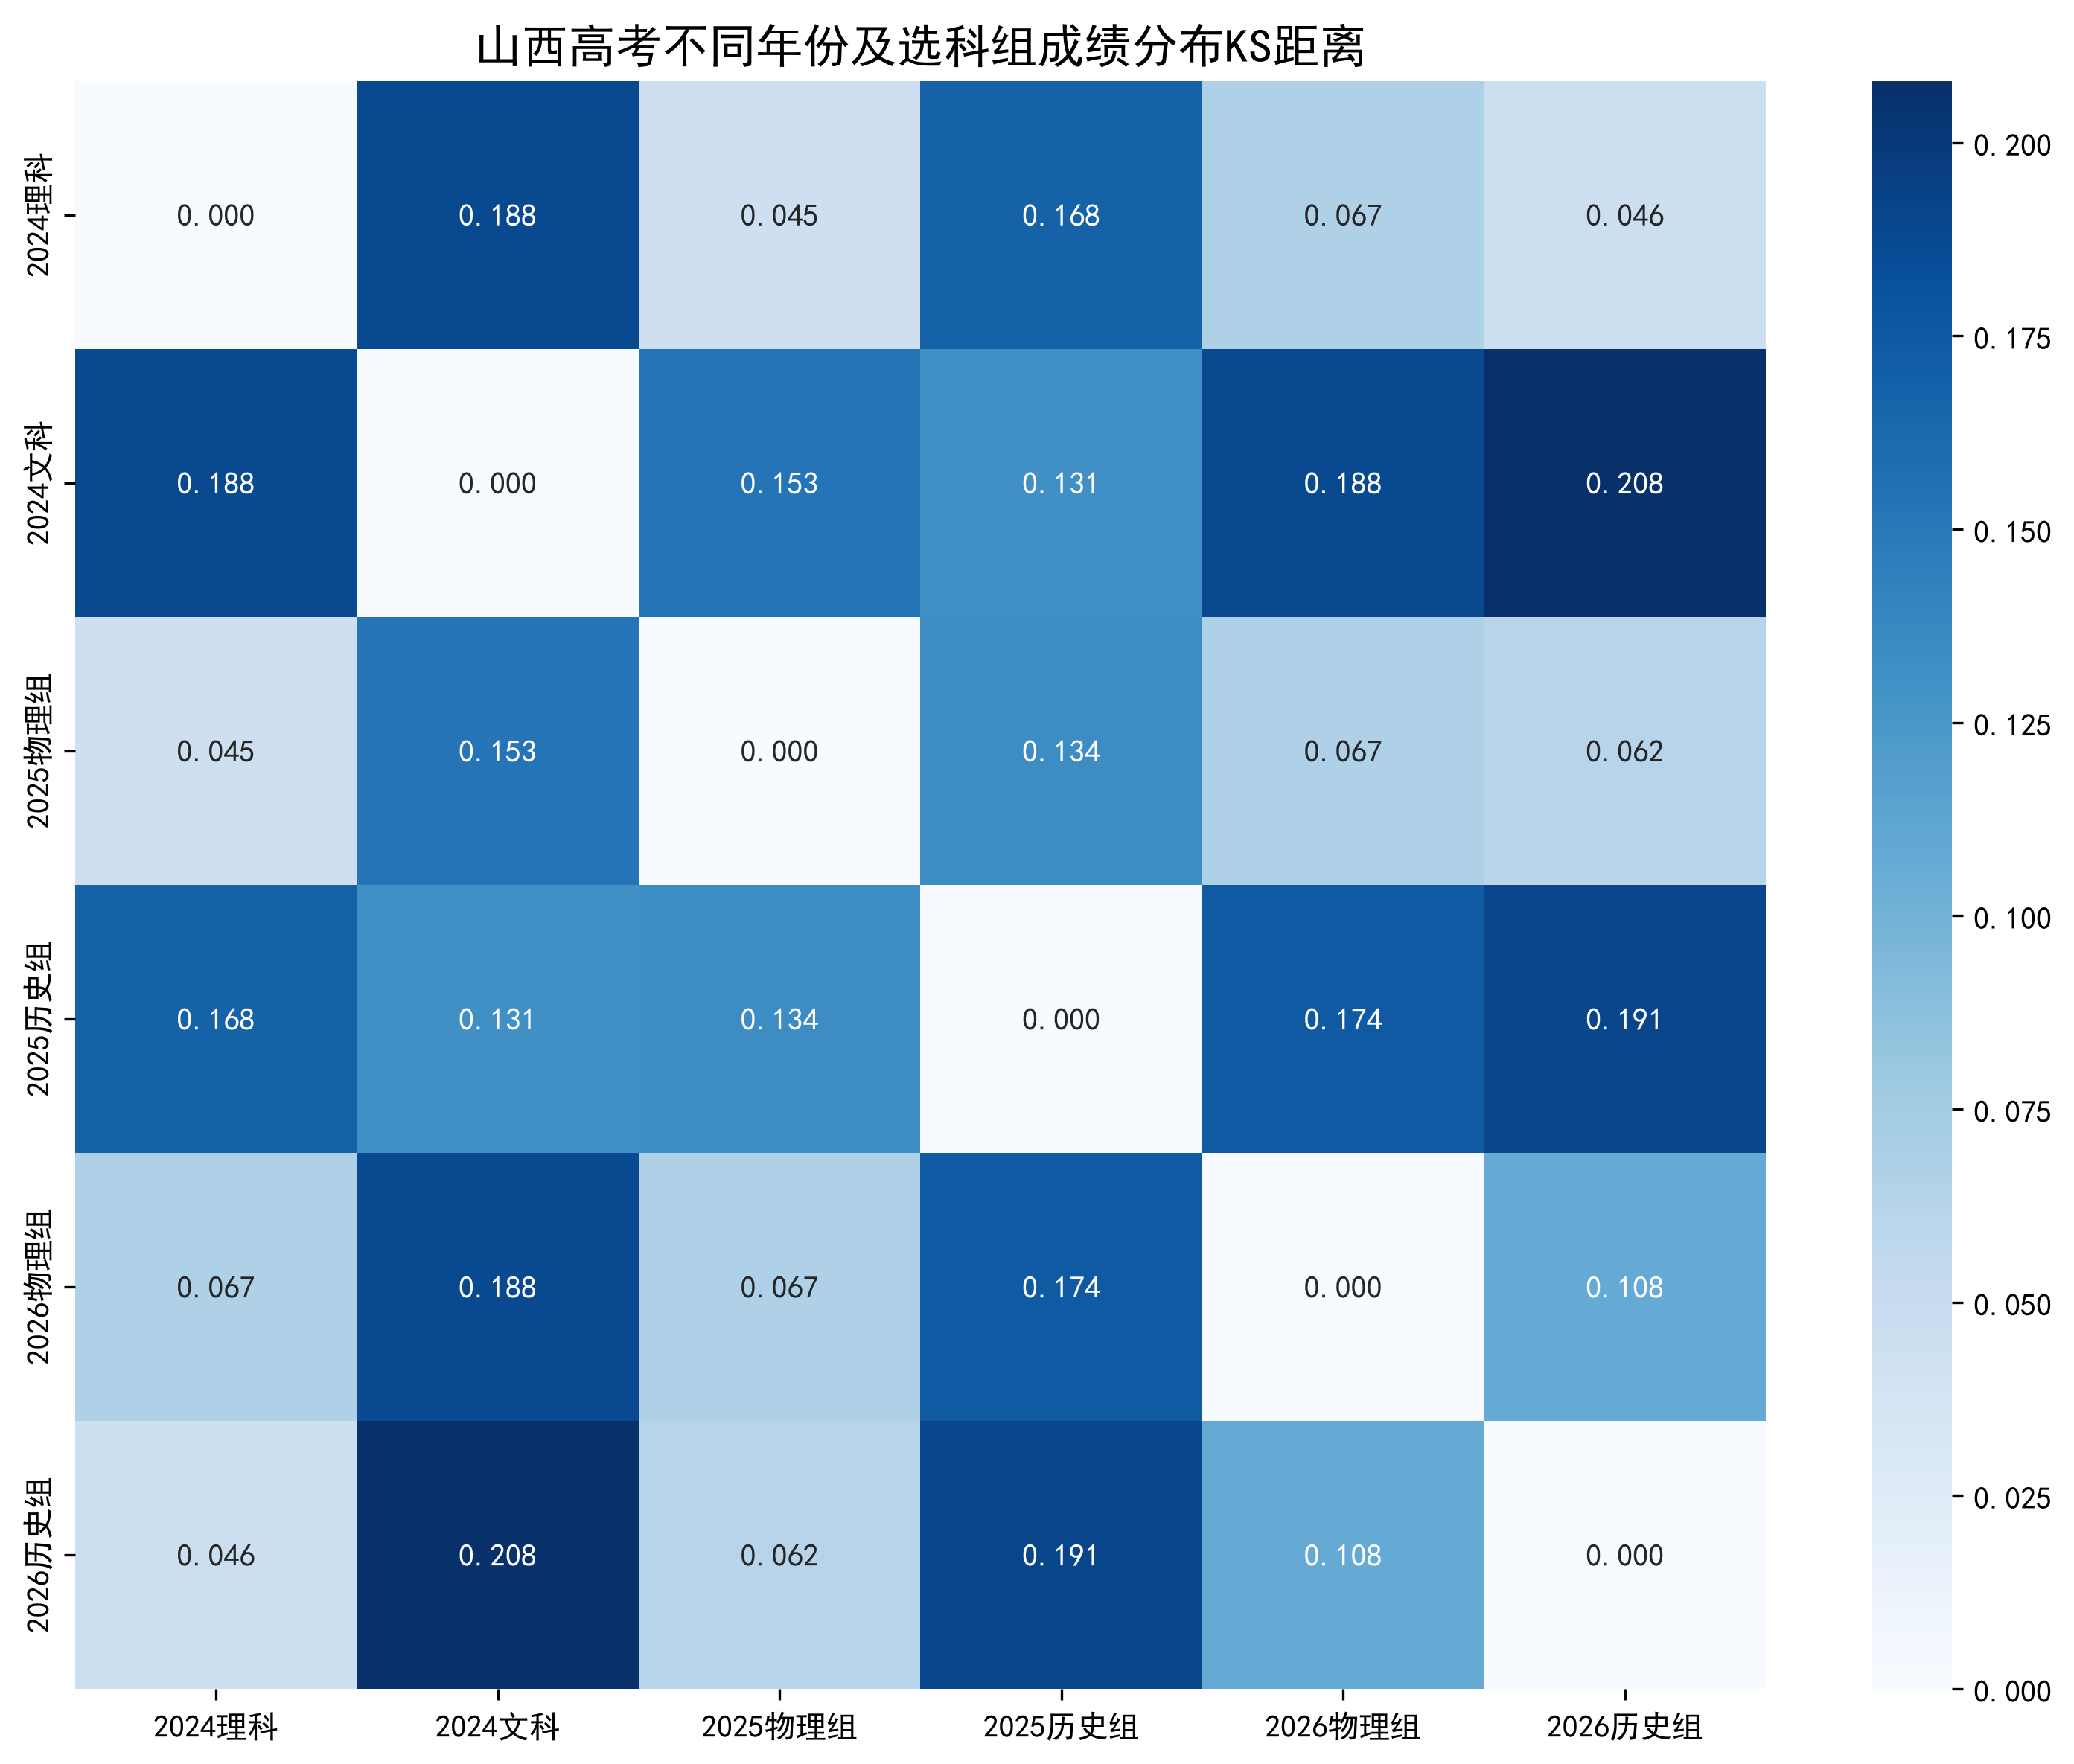

In [4]:
# ==========================================
# 问题1：KS距离计算
# 验证不同年份成绩分布差异
# ==========================================
from scipy.stats import ks_2samp
# ------------------------------------------------
# 两两计算KS距离
# ------------------------------------------------
ks_matrix = pd.DataFrame(
    np.zeros((len(names), len(names))),
    index=names,
    columns=names)
for i in range(len(names)):
    for j in range(len(names)):
        # KS检验
        ks_stat, p_value = ks_2samp(score_data[names[i]],score_data[names[j]])
        # KS统计量D
        ks_matrix.iloc[i, j] = ks_stat
# 保留三位小数
ks_matrix = ks_matrix.round(3)
print("KS距离矩阵：")
display(ks_matrix)
# ------------------------------------------------
# KS距离热力图
# ------------------------------------------------
plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(ks_matrix,annot=True,fmt=".3f",cmap="Blues")
plt.title("山西高考不同年份及选科组成绩分布KS距离",fontsize=15,fontweight="bold")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [5]:
# ==========================================
# 反事实预测：
# 截断偏态正态模型拟合2022-2024旧高考数据
# 加权预测2025旧高考文理分布
# ==========================================
import numpy as np
import pandas as pd
from scipy.stats import skewnorm
from scipy.optimize import minimize


# ==========================================
# 1. 一分一段表转换为成绩样本
# ==========================================
def expand_score(df):
    score = np.repeat(df["分数"].values,df["本分人数"].astype(int).values)
    return score


# ==========================================
# 2. 截断偏态正态负对数似然函数
# ==========================================
def truncated_skewnorm_nll(params,data,lower):
    """
    截断偏态正态负对数似然
    params:
    alpha 偏态参数
    loc   位置参数
    scale 尺度参数
    lower:截断分数线
    """
    alpha, loc, scale = params
    # 保证尺度参数为正
    if scale <= 0:
        return np.inf
    # 偏态正态密度
    pdf = skewnorm.pdf(data,alpha,loc,scale)
    # 截断概率
    cdf_lower = skewnorm.cdf(lower,alpha,loc,scale)
    survival = 1-cdf_lower
    if survival <= 0:
        return np.inf
    # 截断后的密度
    likelihood = pdf / survival
    likelihood[likelihood <= 0] = 1e-12
    return -np.sum(np.log(likelihood))


# ==========================================
# 3. 拟合截断偏态正态模型
# ==========================================
def fit_truncated_skew(data,lower):
    init = [0,# alpha
            np.mean(data),# loc
            np.std(data)# scale
           ]
    result = minimize(truncated_skewnorm_nll,init,args=(data,lower),
             method="Nelder-Mead")
    alpha, loc, scale = result.x
    return {"alpha":alpha,"loc":loc,"scale":scale,"loss":result.fun}


# ==========================================
# 4. 读取2022-2024旧高考数据
# ==========================================
old_files={
    "2022理科":"shanxi_2022_science.csv",
    "2023理科":"shanxi_2023_science.csv",
    "2024理科":"shanxi_2024_science.csv",
    "2022文科":"shanxi_2022_arts.csv",
    "2023文科":"shanxi_2023_arts.csv",
    "2024文科":"shanxi_2024_arts.csv"
}
old_scores={}
for name,file in old_files.items():
    df=pd.read_csv(file)
    df=df[["分数","本分人数","累计人数"]].dropna()
    old_scores[name]=expand_score(df)


# ==========================================
# 5. 拟合2022-2024每一年分布
# ==========================================
params_table=[]
# 根据本科线修改
lower_score=400
for name,data in old_scores.items():
    result=fit_truncated_skew(data,lower_score)
    result["year"]=name
    params_table.append(result)
params_df=pd.DataFrame(params_table)
print("2022-2024截断偏态模型参数")
display(params_df)


# ==========================================
# 6. 基于时间权重预测2025参数
# ==========================================
def predict_parameter(values):
    """
    加权预测
    2022 权重0.2
    2023 权重0.3
    2024 权重0.5
    """
    weights=np.array([0.2,0.3,0.5])
    values=np.array(values)
    prediction=np.sum(values*weights)
    return prediction
predict_result={}
for group in ["理科","文科"]:
    temp=params_df[params_df["year"].str.contains(group)]
    predict_result[group]={}
    for col in ["alpha","loc","scale"]:
        predict_result[group][col]=predict_parameter(temp[col].values)
predict_df=pd.DataFrame(predict_result).T
print("2025旧高考反事实模型参数预测")
display(predict_df)


# ==========================================
# 7. 根据预测参数生成2025反事实成绩分布
# ==========================================
def generate_distribution(params,n=100000):
    sample=skewnorm.rvs(
        params["alpha"],
        loc=params["loc"],
        scale=params["scale"],
        size=n*3
    )
    # 保留本科线上成绩
    sample=sample[sample>=lower_score]
    return sample[:n]
counterfactual={}
for group in ["理科","文科"]:
    counterfactual[group]=generate_distribution(predict_result[group])
print("2025旧高考反事实分布生成完成")

2022-2024截断偏态模型参数


,alpha,loc,scale,loss,year
0,-0.000682,476.043152,60.794829,494371.167059,2022理科
1,-0.002909,406.203703,100.670691,505800.938589,2023理科
2,-0.000850,490.127978,70.354304,548254.620672,2024理科
3,0.000147,496.493569,35.001533,127611.867532,2022文科
4,-0.000664,463.029227,48.826108,127802.036526,2023文科
5,-0.000027,499.682255,41.529604,126074.824950,2024文科


2025旧高考反事实模型参数预测


,alpha,loc,scale
理科,-0.001434,462.13373,77.537325
文科,-0.000183,488.04861,42.412941


2025旧高考反事实分布生成完成


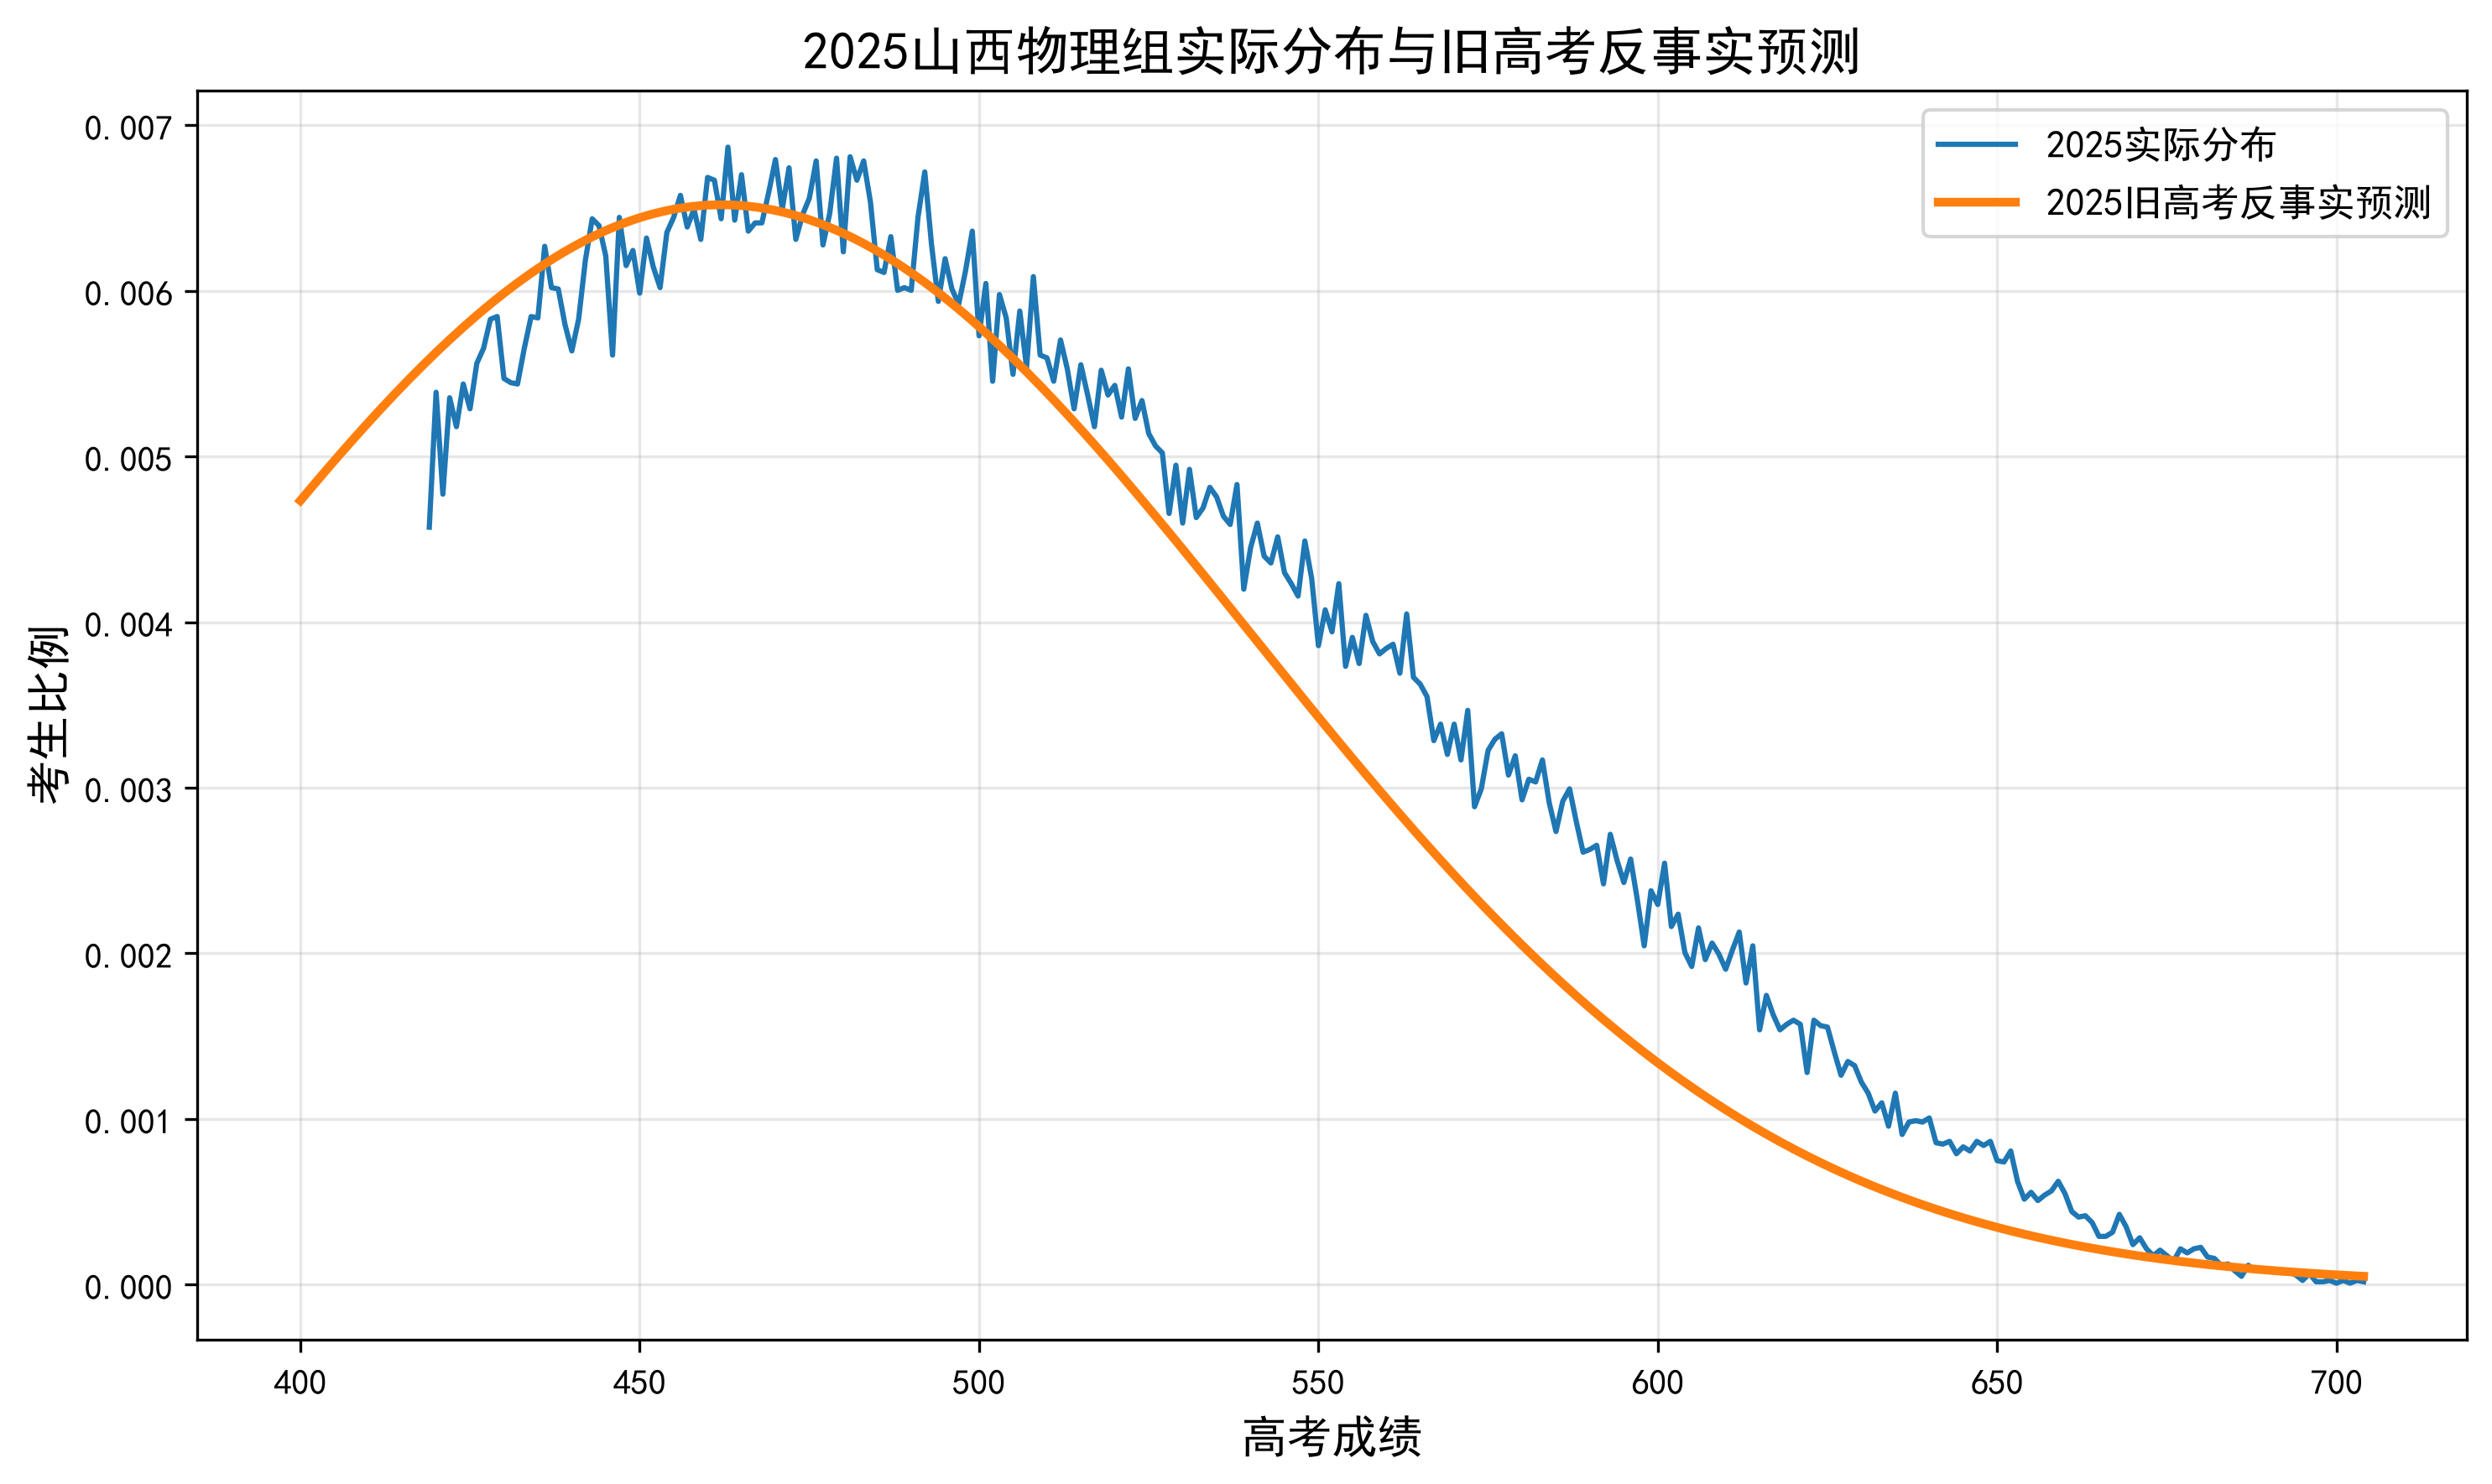

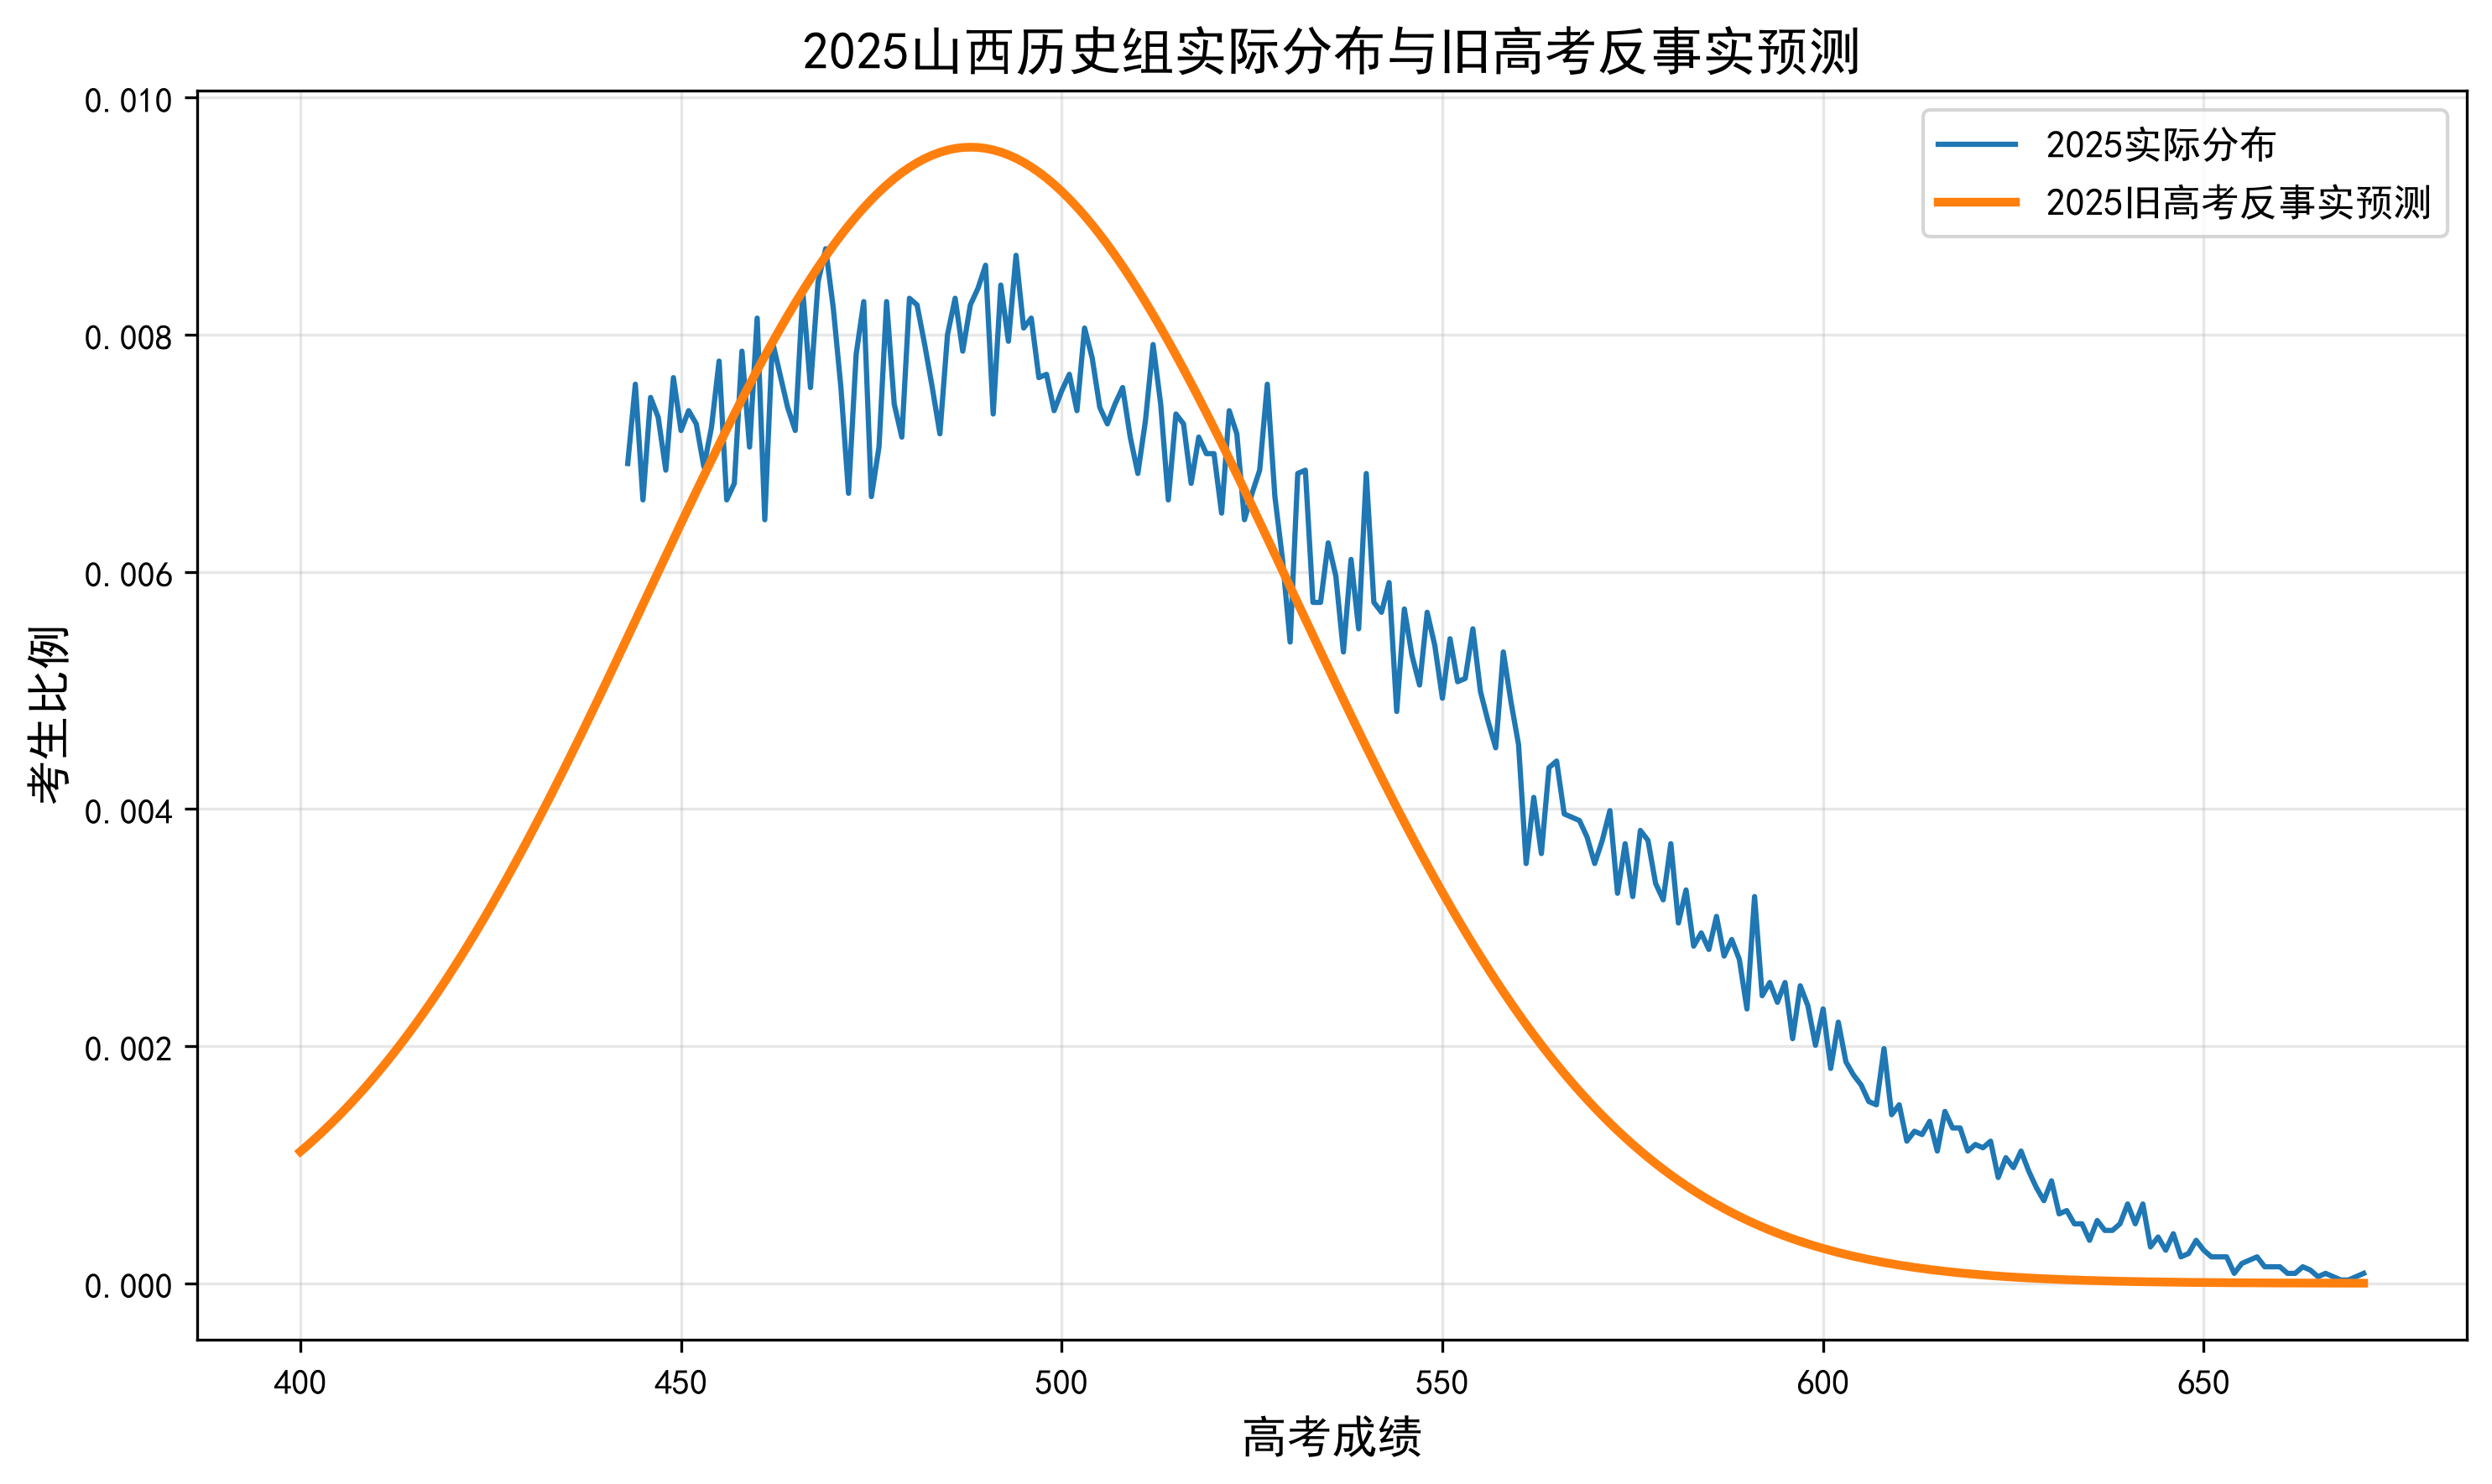

In [6]:
# ==========================================
# 11. 两曲线对比图
#
# 实际数据
# 旧高考反事实预测
#
# ==========================================
from scipy.stats import skewnorm


# ==========================================
# 截断偏态正态密度函数（绘图使用）
# ==========================================
def truncated_skew_density(x,alpha,loc,scale,lower):
    # 偏态正态原始密度
    pdf = skewnorm.pdf(x,alpha,loc,scale)
    # 截断归一化因子
    cdf_lower = skewnorm.cdf(lower,alpha,loc,scale)
    return pdf / (1-cdf_lower)
def plot_three_lines(csv_file,counter_params,title,lower=400):
    plt.figure(figsize=(10,6),dpi=300)
    # ----------------------------
    # 1. 原始一分一段比例
    # ----------------------------
    df=pd.read_csv(csv_file)
    df=df[["分数","本分人数"]]
    df=df.sort_values("分数")
    score=df["分数"].values
    real_prob=(df["本分人数"].values/df["本分人数"].sum())
    # 蓝线：真实2025分布
    plt.plot(score,real_prob,linewidth=1.5,label="2025实际分布")
    # ----------------------------
    # x轴范围
    # ----------------------------
    x=np.arange(lower,score.max()+1)
    # ----------------------------
    # 2. 旧高考反事实预测
    # ----------------------------
    counter_density=truncated_skew_density(
        x,
        counter_params["alpha"],
        counter_params["loc"],
        counter_params["scale"],
        lower
    )

    # 转化为离散概率比例
    counter_density=(counter_density/counter_density.sum())
    # 绿色：旧高考预测
    plt.plot(x,counter_density,linewidth=2.5,label="2025旧高考反事实预测")
    # ----------------------------
    # 图像美化
    # ----------------------------
    plt.xlabel("高考成绩",fontsize=13)
    plt.ylabel("考生比例",fontsize=13)
    plt.title(title,fontsize=15,fontweight="bold")
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ==========================================
# 物理组
# ==========================================
plot_three_lines(
    "shanxi_2025_physics.csv",
    predict_result["理科"],
    "2025山西物理组实际分布与旧高考反事实预测",
    lower=400
)



# ==========================================
# 历史组
# ==========================================
plot_three_lines(
    "shanxi_2025_history.csv",
    predict_result["文科"],
    "2025山西历史组实际分布与旧高考反事实预测",
    lower=400

)

In [7]:
# ==========================================
# 8. 历史数据拟合效果评价
# ==========================================
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import wasserstein_distance
def evaluate_fit(data,params,lower):
    """
    评价截断偏态模型拟合效果
    data:
    原始成绩样本
    params:
    拟合参数
    """
    # 分数范围
    x=np.arange(lower,data.max()+1)
    # 真实概率
    real_counts=np.array([np.sum(data==i)for i in x])
    real_prob=(real_counts/real_counts.sum())
    # 理论密度
    pred_prob=truncated_skew_density(x,params["alpha"],params["loc"],params["scale"],lower)
    pred_prob=(pred_prob/pred_prob.sum())
    rmse=np.sqrt(mean_squared_error(real_prob,pred_prob))
    mae=mean_absolute_error(real_prob,pred_prob)
    wd=wasserstein_distance(x,x,u_weights=real_prob,v_weights=pred_prob)
    return {"RMSE":rmse,"MAE":mae,"Wasserstein":wd}
fit_result=[]
for _,row in params_df.iterrows():
    name=row["year"]
    result=evaluate_fit(old_scores[name],row,lower_score)
    result["年份"]=name
    fit_result.append(result)
fit_eval=pd.DataFrame(fit_result)
print("2022-2024历史拟合效果评价")
display(fit_eval)

2022-2024历史拟合效果评价


,RMSE,MAE,Wasserstein,年份
0,0.001418,0.000825,3.844240,2022理科
1,0.000371,0.000300,4.324031,2023理科
2,0.001178,0.000741,4.143321,2024理科
3,0.002536,0.001718,6.099586,2022文科
4,0.002141,0.001337,4.631324,2023文科
5,0.002242,0.001521,6.640398,2024文科


In [8]:
# ==========================================
# 8. 2025反事实预测评价
# 真实2025分布 VS 预测旧高考分布
# ==========================================
from scipy.stats import wasserstein_distance
def evaluate_prediction(csv_file, params, lower=400):
    # --------真实2025分布--------
    df=pd.read_csv(csv_file)
    df=df.sort_values("分数")
    score=df["分数"].values
    real_prob=(df["本分人数"].values/df["本分人数"].sum())
    # --------预测旧高考分布--------
    x=np.arange(lower,score.max()+1)
    pred_prob=truncated_skew_density(
        x,
        params["alpha"],
        params["loc"],
        params["scale"],
        lower
    )
    pred_prob=(pred_prob/pred_prob.sum())
    # --------统一分数范围--------
    scores=np.arange(max(score.min(),x.min()),min(score.max(),x.max())+1)
    real_dict=dict(zip(score,real_prob))
    pred_dict=dict(zip(x,pred_prob))
    p=np.array([real_dict.get(i,0) for i in scores])
    q=np.array([pred_dict.get(i,0) for i in scores])
    p/=p.sum()
    q/=q.sum()
    # Wasserstein
    wd=wasserstein_distance(scores,scores,u_weights=p,v_weights=q)
    # KS距离
    ks=np.max(np.abs(np.cumsum(p)-np.cumsum(q)))
    return wd,ks


# ==========================================
# 物理组
# ==========================================
physics=evaluate_prediction("shanxi_2025_physics.csv",predict_result["理科"])


# ==========================================
# 历史组
# ==========================================
history=evaluate_prediction("shanxi_2025_history.csv",predict_result["文科"])
result=pd.DataFrame([physics,history],columns=["Wasserstein距离","KS距离"],index=["2025物理组","2025历史组"])
print("2025反事实预测评价")
display(result)

2025反事实预测评价


,Wasserstein距离,KS距离
2025物理组,9.877953,0.070342
2025历史组,15.362441,0.160145


将预测结果与实际高考数据对比分离“制度变革效应”和“自然年际波动”各自的贡献。
我的思路是：总变化=2025新-2024年旧（真实）
自然年际波动 =  2025旧-2024旧（含预测）
制度变革效应 = 2025新-2025旧（含预测）

In [9]:
# ==========================================
# 9. 新高考效应分解
# ==========================================
from scipy.stats import wasserstein_distance


# ==========================================
# 读取真实一分一段表
# 转换为离散概率分布
# ==========================================
def read_real_distribution(file):
    df=pd.read_csv(file)
    df=df[["分数","本分人数"]].sort_values("分数")
    score=df["分数"].values
    prob=(df["本分人数"].values/df["本分人数"].sum())
    return score,prob


# ==========================================
# 参数生成理论分布
# ==========================================
def generate_predict_distribution(params,lower=400,upper=750):
    x=np.arange(lower,upper+1)
    density=truncated_skew_density(x,params["alpha"],params["loc"],params["scale"],lower)
    density=(density/density.sum())
    return x,density


# ==========================================
# Wasserstein距离
# ==========================================
def W_real_predict(real_file,params,lower=400):
    # 真实分布
    df=pd.read_csv(real_file)
    df=df[["分数","本分人数"]].sort_values("分数")
    s1=df["分数"].values
    p1=(df["本分人数"].values/df["本分人数"].sum())
    # 预测理论分布
    s2=np.arange(lower,s1.max()+1)
    p2=truncated_skew_density(s2,params["alpha"],params["loc"],params["scale"],lower)
    p2=p2/p2.sum()


    # ==========================
    # 对齐分数区间
    # ==========================
    low=max(s1.min(),s2.min())
    high=min(s1.max(),s2.max())
    x=np.arange(low,high+1)
    p=np.array([
        p1[np.where(s1==i)[0][0]]
        if i in s1 else 0
        for i in x
    ])
    q=np.array([
        p2[np.where(s2==i)[0][0]]
        if i in s2 else 0
        for i in x
    ])
    p=p/p.sum()
    q=q/q.sum()
    return wasserstein_distance(x,x,u_weights=p,v_weights=q)


# ==========================================
# 物理组
# ==========================================
# 自然年际波动：2024旧理科 → 2025旧高考反事实
physics_time=W_real_predict("shanxi_2024_science.csv",predict_result["理科"])
# 制度变革效应：2025新物理 → 2025旧高考反事实
physics_policy=W_real_predict("shanxi_2025_physics.csv",predict_result["理科"])


# ==========================================
# 历史组
# ==========================================
# 自然年际波动：
# 2024旧文科 → 2025旧高考反事实
history_time=W_real_predict("shanxi_2024_arts.csv",predict_result["文科"])
# 制度变革效应：
# 2025新历史 → 2025旧高考反事实
history_policy=W_real_predict("shanxi_2025_history.csv",predict_result["文科"])


# ==========================================
# 汇总结果
# ==========================================
effect=pd.DataFrame({
"自然年际波动":[physics_time,history_time],
"制度变革效应":[physics_policy,history_policy]
},
index=["2025物理组","2025历史组"])
# 贡献比例
effect["自然贡献%"]=(effect["自然年际波动"]/(effect["自然年际波动"]+effect["制度变革效应"])*100)
effect["制度贡献%"]=(effect["制度变革效应"]/(effect["自然年际波动"]+effect["制度变革效应"])*100)
display(effect)

,自然年际波动,制度变革效应,自然贡献%,制度贡献%
2025物理组,5.784795,9.877953,36.933461,63.066539
2025历史组,5.866737,15.362441,27.635251,72.364749
